# LIBERO cached-overfit and controller-trajectory analysis

This notebook separates three questions that are easy to mix together:

1. Did denoising loss decrease?
2. Did the real diffusion sampler reproduce the cached commands?
3. When those sampled commands are sent to LIBERO's controller, does the resulting physical state trajectory follow the demonstration?

The state comparison is produced by actual simulator execution. It does not integrate `dx/dy/dz` manually. The notebook initializes two identical LIBERO environments from the exact demonstration simulator state, executes recorded commands in one and sampled RDT commands in the other, then compares their resulting observations across time.

## 1. Setup

In [14]:
import os
os.environ.setdefault('MUJOCO_GL', 'egl')
os.environ.setdefault('XDG_CACHE_HOME', '/tmp/thinkflow-cache')
os.environ.setdefault('MPLCONFIGDIR', '/tmp/thinkflow-matplotlib')

import gc
import json
import sys
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'scripts').exists():
            return candidate
    raise RuntimeError('Start Jupyter from inside the ThinkFlow-RDT-1B repository')

REPO_ROOT = find_repo_root(Path.cwd().resolve())
LIBERO_ROOT = Path('/home/ubuntu/LIBERO')
for path in (REPO_ROOT, REPO_ROOT / 'src', REPO_ROOT / 'scripts', LIBERO_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display

from inspect_libero_outputs import install_robosuite_mujoco_compatibility
from thinkflow_rdt.adapters.libero import (
    libero_image_to_rgb,
    libero_observation_to_rdt,
    libero_orientation_to_ortho6d,
    ortho6d_to_rotation_matrix,
    rdt_action_to_libero,
)

install_robosuite_mujoco_compatibility()
print('Repository:', REPO_ROOT)
print('Python:', sys.executable)

Repository: /home/ubuntu/ThinkFlow-RDT-1B
Python: /home/ubuntu/ThinkFlow-RDT-1B/.venv/bin/python


In [26]:
OVERFIT_ROOT = REPO_ROOT / 'outputs/libero_object_task0_10demo_overfit'
REPORT_PATH = OVERFIT_ROOT / 'report.json'
SAMPLES_PATH = OVERFIT_ROOT / 'sampled_predictions.pt'
SNAPSHOT_NAME = None      # None selects the latest saved sampling checkpoint
SAMPLE_LOCAL_INDEX = 0   # index within the saved sampling-audit subset
DIFFUSION_REPEAT = 0     # usually 0; validated against the saved snapshot
TASK_ID = 0
CAMERA_SIZE = 128
RUN_CONTROLLER_REPLAY = True

assert REPORT_PATH.exists(), REPORT_PATH
assert SAMPLES_PATH.exists(), SAMPLES_PATH
report = json.loads(REPORT_PATH.read_text(encoding='utf-8'))
suite = report['configuration']['suite']
manifest_path = Path(report['manifest'])
if not manifest_path.is_absolute():
    manifest_path = REPO_ROOT / manifest_path
configured_indices = report['configuration']['sample_indices']
audit_indices = report['configuration'].get('real_sampling_audit_indices', configured_indices)
print('Suite:', suite)
print('Artifact:', report['artifact'])
print('Training conditions:', len(configured_indices))
print('Sampling audit conditions:', len(audit_indices))
display(report['rollout'])

Suite: libero_object
Artifact: /home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_cached_overfit/artifact
Training conditions: 8
Sampling audit conditions: 8


{'episodes': 2,
 'successes': 0,
 'success_rate': 0.0,
 'tasks': [{'task_id': 0,
   'instruction': 'pick up the alphabet soup and place it in the basket',
   'episodes': 2,
   'successes': 0,
   'success_rate': 0.0}],
 'requested_episodes': 2,
 'complete': True,
 'output_dir': '/home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_cached_overfit/rollout_20260808_201638'}

## 2. Training loss versus real diffusion sampling

{'final_horizon_RMSE': {'1': {'command_rmse_7d': 0.010754739865660667,
   'motion_rmse_6d': 0.0111747607588768,
   'gripper_rmse': 0.007771703414618969,
   'valid_commands': 24},
  '4': {'command_rmse_7d': 0.010096081532537937,
   'motion_rmse_6d': 0.010502845980226994,
   'gripper_rmse': 0.007187305483967066,
   'valid_commands': 96},
  '8': {'command_rmse_7d': 0.00890741404145956,
   'motion_rmse_6d': 0.009259105660021305,
   'gripper_rmse': 0.006403748411685228,
   'valid_commands': 192},
  '64': {'command_rmse_7d': 0.057185739278793335,
   'motion_rmse_6d': 0.027945302426815033,
   'gripper_rmse': 0.13492895662784576,
   'valid_commands': 1536}},
 'gripper': {'positive_class': 'raw_command_ge_0',
  'accuracy': 0.9954427083333334,
  'precision': 0.991869918699187,
  'recall': 0.9967320261437909,
  'f1': 0.9942950285248574,
  'tp': 610,
  'fp': 5,
  'fn': 2,
  'tn': 919},
 'overall_sign_agreement': 0.7242373511904762,
 'overall_saturation_fraction': 0.04724702380952381}

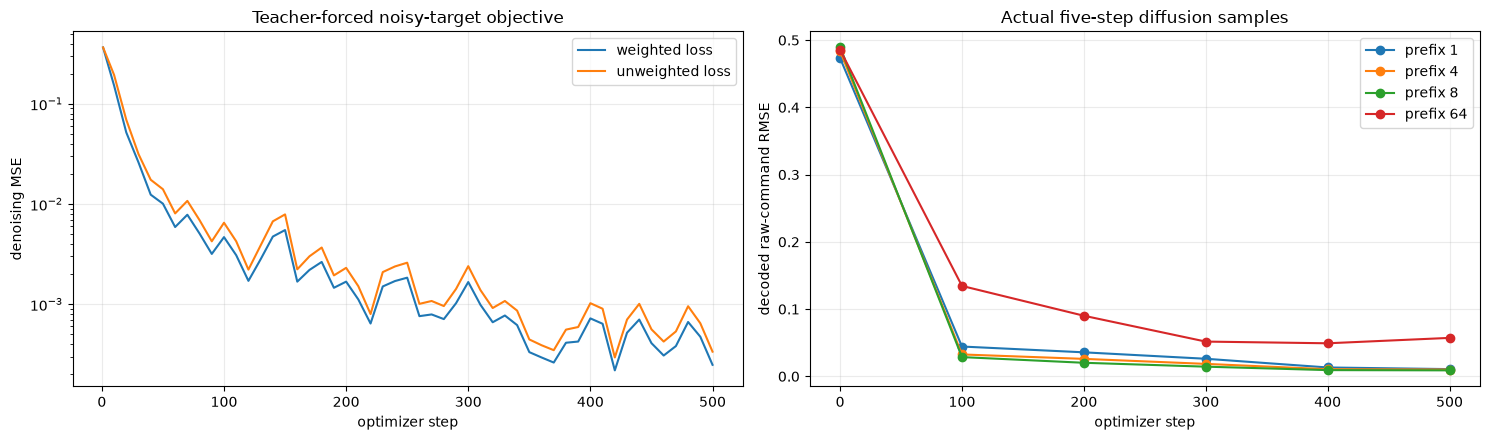

In [27]:
def reported_weighted_loss(row):
    return row.get('weighted_imitation_loss', row.get('weighted_denoising_loss'))

loss_events = [row for row in report['history'] if reported_weighted_loss(row) is not None]
sampling_events = [row for row in report['history'] if 'real_sampling' in row]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].plot([row['step'] for row in loss_events], [reported_weighted_loss(row) for row in loss_events], label='weighted loss')
axes[0].plot([row['step'] for row in loss_events], [row['unweighted_denoising_loss'] for row in loss_events], label='unweighted loss')
axes[0].set_yscale('log'); axes[0].set_xlabel('optimizer step'); axes[0].set_ylabel('denoising MSE')
axes[0].set_title('Teacher-forced noisy-target objective'); axes[0].legend(); axes[0].grid(alpha=0.25)
for horizon in (1, 4, 8, 64):
    rows = [(event['step'], event['real_sampling']['horizon_rmse'][str(horizon)]) for event in sampling_events]
    rows = [(step, values) for step, values in rows if values is not None]
    axes[1].plot([step for step, _ in rows], [values['command_rmse_7d'] for _, values in rows], marker='o', label=f'prefix {horizon}')
axes[1].set_xlabel('optimizer step'); axes[1].set_ylabel('decoded raw-command RMSE')
axes[1].set_title('Actual five-step diffusion samples'); axes[1].legend(); axes[1].grid(alpha=0.25)
plt.tight_layout()

final_sampling = sampling_events[-1]['real_sampling']
display({
    'final_horizon_RMSE': final_sampling['horizon_rmse'],
    'gripper': final_sampling['gripper'],
    'overall_sign_agreement': final_sampling['overall_sign_agreement'],
    'overall_saturation_fraction': final_sampling['overall_saturation_fraction'],
})

### What the report already proves

The training-condition count and the smaller saved sampling-audit subset are printed above. Sampling metrics measure only that fixed audit subset, while the rollout remains a closed-loop test.

A rollout re-infers after each configured action chunk. Once execution drifts from demonstrated observations, later predictions may be outside the training distribution. A low cached RMSE therefore does not by itself imply closed-loop task success.

## 3. Resolve a saved sample to its exact demonstration

In [28]:
from thinkflow_rdt.data import CachedFeatureDataset, ONLINE_SIGLIP_REQUIRED_KEYS

dataset = CachedFeatureDataset(manifest_path, required_keys=ONLINE_SIGLIP_REQUIRED_KEYS)
training_indices = [int(index) for index in report['configuration']['sample_indices']]
# New all-sample runs retain predictions only for a fixed audit subset.
# Older tiny runs sampled every training condition and have no audit key.
snapshot_indices = [
    int(index)
    for index in report['configuration'].get(
        'real_sampling_audit_indices',
        training_indices,
    )
]
if not 0 <= SAMPLE_LOCAL_INDEX < len(snapshot_indices):
    raise IndexError(SAMPLE_LOCAL_INDEX)
dataset_index = snapshot_indices[SAMPLE_LOCAL_INDEX]
cached_sample = dataset[dataset_index]
sample_metadata = {
    key: cached_sample[key]
    for key in ('dataset_id', 'episode_id', 'step_idx')
}
episode_stem, demo_name = sample_metadata['episode_id'].rsplit(':', 1)
anchor_step = int(sample_metadata['step_idx'])
demo_path = REPO_ROOT / 'libero-dataset' / suite / f'{episode_stem}.hdf5'
assert demo_path.exists(), demo_path

snapshots = torch.load(SAMPLES_PATH, map_location='cpu', weights_only=True)
available_snapshots = sorted(snapshots)
if not available_snapshots:
    raise ValueError(f'No saved sampling checkpoints in {SAMPLES_PATH}')
if SNAPSHOT_NAME is None:
    SNAPSHOT_NAME = available_snapshots[-1]
elif SNAPSHOT_NAME not in snapshots:
    raise KeyError(f'{SNAPSHOT_NAME!r} is unavailable; choose one of {available_snapshots}')
snapshot = snapshots[SNAPSHOT_NAME]
fixed_count = len(snapshot_indices)
prediction_count = int(snapshot['prediction_10d'].shape[0])
if fixed_count == 0 or prediction_count % fixed_count:
    raise ValueError(
        f'Snapshot has {prediction_count} predictions for {fixed_count} audit conditions'
    )
repeat_count = prediction_count // fixed_count
if not 0 <= DIFFUSION_REPEAT < repeat_count:
    raise IndexError(DIFFUSION_REPEAT)
trajectory_index = DIFFUSION_REPEAT * fixed_count + SAMPLE_LOCAL_INDEX
valid_mask = snapshot['time_mask'][trajectory_index].numpy().astype(bool)
predicted_10d = snapshot['prediction_10d'][trajectory_index].numpy()[valid_mask]
target_10d = snapshot['target_10d'][trajectory_index].numpy()[valid_mask]
predicted_commands = rdt_action_to_libero(predicted_10d)
target_commands = rdt_action_to_libero(target_10d)

with h5py.File(demo_path, 'r') as handle:
    demo = handle['data'][demo_name] if 'data' in handle else handle[demo_name]
    source_actions_all = np.asarray(demo['actions'], dtype=np.float32)[:, :7]
    simulator_states_all = np.asarray(demo['states'], dtype=np.float64)
    obs = demo['obs']
    position_key = 'ee_pos' if 'ee_pos' in obs else 'robot0_eef_pos'
    orientation_key = 'ee_ori' if 'ee_ori' in obs else 'robot0_eef_quat'
    gripper_key = 'gripper_states' if 'gripper_states' in obs else 'robot0_gripper_qpos'
    recorded_states_all = np.concatenate([
        np.asarray(obs[position_key], dtype=np.float32)[..., :3],
        libero_orientation_to_ortho6d(np.asarray(obs[orientation_key])),
        np.asarray(obs[gripper_key], dtype=np.float32)[..., :2],
    ], axis=-1)
    primary_key = 'agentview_rgb' if 'agentview_rgb' in obs else 'agentview_image'
    recorded_primary = libero_image_to_rgb(np.asarray(obs[primary_key]))

source_commands = source_actions_all[anchor_step:anchor_step + len(target_commands)]
print('Cache sample:', sample_metadata)
print('Training conditions:', len(training_indices))
print('Snapshot audit conditions:', fixed_count, 'sampling repeats:', repeat_count)
print('Snapshot trajectory index:', trajectory_index, 'of', snapshot['prediction_10d'].shape[0])
print('Demo:', demo_path.name, demo_name, 'anchor step:', anchor_step)
print('Valid sampled horizon:', len(predicted_commands))
print('Cache target vs source max absolute difference:', np.max(np.abs(target_commands - source_commands)))
assert np.allclose(target_commands, source_commands, atol=1e-5)

Cache sample: {'dataset_id': 'libero_object', 'episode_id': 'pick_up_the_alphabet_soup_and_place_it_in_the_basket_demo:demo_0', 'step_idx': '0'}
Training conditions: 8
Snapshot audit conditions: 8 sampling repeats: 3
Snapshot trajectory index: 0 of 24
Demo: pick_up_the_alphabet_soup_and_place_it_in_the_basket_demo.hdf5 demo_0 anchor step: 0
Valid sampled horizon: 64
Cache target vs source max absolute difference: 3.7252903e-09


## 4. Ground-truth commands versus sampled commands

[{'dimension': 'dx',
  'MAE': 0.025153424590826035,
  'RMSE': 0.030440645292401314,
  'correlation': 0.9931855313570045,
  'sign_agreement': 0.875,
  'predicted_saturation': 0.0},
 {'dimension': 'dy',
  'MAE': 0.03616827353835106,
  'RMSE': 0.04248250275850296,
  'correlation': 0.9939084092827758,
  'sign_agreement': 0.8125,
  'predicted_saturation': 0.0},
 {'dimension': 'dz',
  'MAE': 0.0274079330265522,
  'RMSE': 0.03845389932394028,
  'correlation': 0.998418419718763,
  'sign_agreement': 0.734375,
  'predicted_saturation': 0.0},
 {'dimension': 'dRx',
  'MAE': 0.005396313965320587,
  'RMSE': 0.0068071577697992325,
  'correlation': 0.9776426975994322,
  'sign_agreement': 0.46875,
  'predicted_saturation': 0.0},
 {'dimension': 'dRy',
  'MAE': 0.0068728504702448845,
  'RMSE': 0.009141962043941021,
  'correlation': 0.965480931898734,
  'sign_agreement': 0.671875,
  'predicted_saturation': 0.0},
 {'dimension': 'dRz',
  'MAE': 0.003847797168418765,
  'RMSE': 0.004404960200190544,
  'correl

Overall raw-command RMSE: 0.025660636
Gripper sign agreement: 1.0


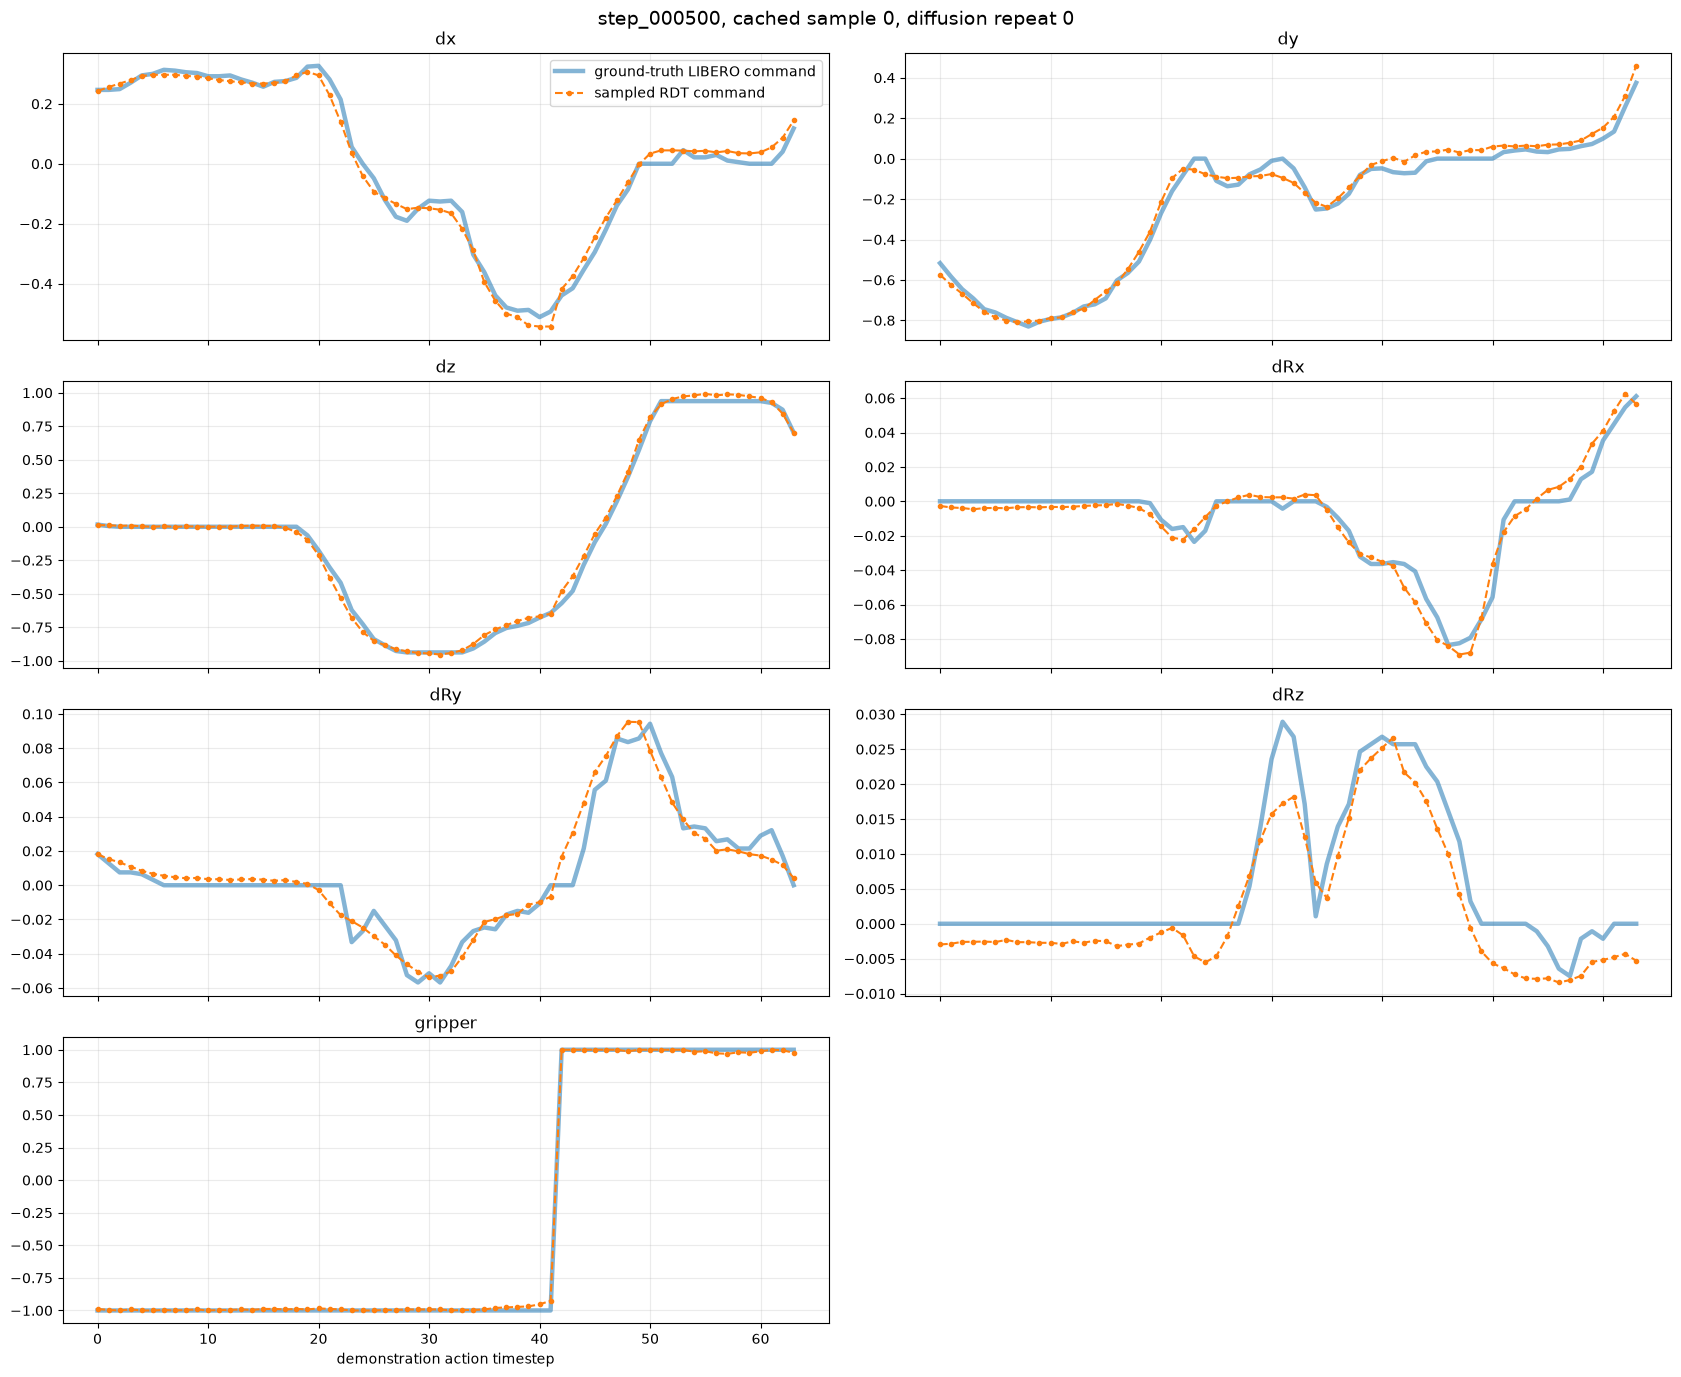

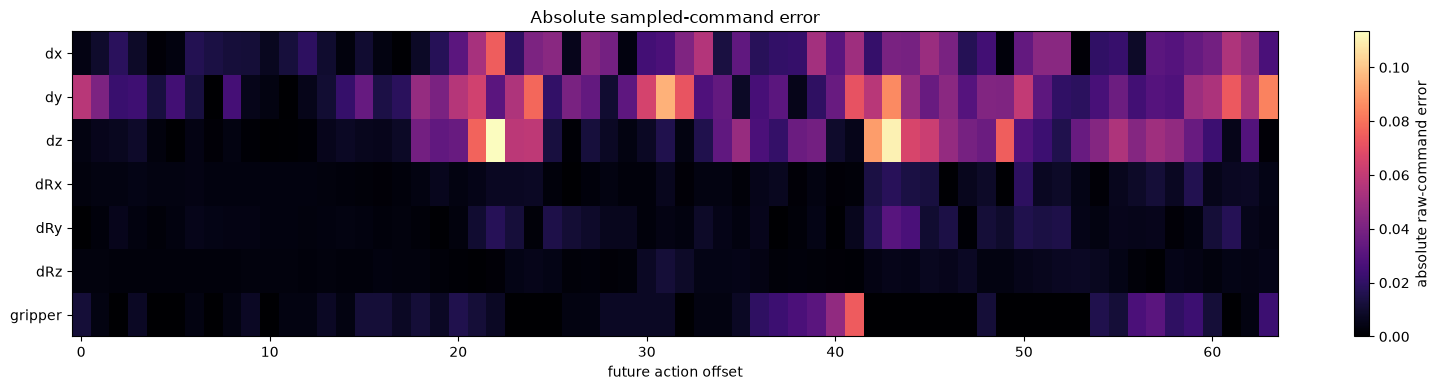

In [49]:
action_names = ['dx', 'dy', 'dz', 'dRx', 'dRy', 'dRz', 'gripper']
action_steps = anchor_step + np.arange(len(predicted_commands))
action_error = predicted_commands - source_commands
metric_rows = []
for dim, name in enumerate(action_names):
    ground_truth = source_commands[:, dim]
    prediction = predicted_commands[:, dim]
    corr = np.corrcoef(ground_truth, prediction)[0, 1] if ground_truth.std() > 1e-8 and prediction.std() > 1e-8 else np.nan
    metric_rows.append({
        'dimension': name,
        'MAE': float(np.mean(np.abs(action_error[:, dim]))),
        'RMSE': float(np.sqrt(np.mean(action_error[:, dim] ** 2))),
        'correlation': float(corr),
        'sign_agreement': float(np.mean(np.sign(ground_truth) == np.sign(prediction))),
        'predicted_saturation': float(np.mean(np.abs(prediction) >= 1 - 1e-6)),
    })
display(metric_rows)
print('Overall raw-command RMSE:', np.sqrt(np.mean(action_error ** 2)))
print('Gripper sign agreement:', np.mean(np.sign(predicted_commands[:, 6]) == np.sign(source_commands[:, 6])))

fig, axes = plt.subplots(4, 2, figsize=(17, 14), sharex=True)
axes = axes.ravel()
for dim, name in enumerate(action_names):
    axes[dim].plot(action_steps, source_commands[:, dim], color='tab:blue', linewidth=3.2, alpha=0.55, label='ground-truth LIBERO command')
    axes[dim].plot(action_steps, predicted_commands[:, dim], color='tab:orange', linestyle='--', marker='o', markersize=3, linewidth=1.5, label='sampled RDT command')
    axes[dim].set_title(name); axes[dim].grid(alpha=0.25)
    if dim == 0: axes[dim].legend()
axes[-1].axis('off')
for ax in axes[-2:]: ax.set_xlabel('demonstration action timestep')
fig.suptitle(f'{SNAPSHOT_NAME}, cached sample {SAMPLE_LOCAL_INDEX}, diffusion repeat {DIFFUSION_REPEAT}', fontsize=14)
plt.tight_layout()

plt.figure(figsize=(16, 4))
plt.imshow(np.abs(action_error).T, aspect='auto', interpolation='nearest', cmap='magma')
plt.yticks(np.arange(7), action_names); plt.xlabel('future action offset'); plt.title('Absolute sampled-command error')
plt.colorbar(label='absolute raw-command error'); plt.tight_layout()

## 5. Send both command sequences through the real LIBERO controller

Both replays begin from `demo/states[anchor_step]`. The first executes the recorded commands and serves as a simulator-replay control. The second executes the saved RDT commands. Each state below is read from LIBERO after `env.step(action)`; no kinematic approximation is used.

In [30]:
from libero.libero.benchmark import get_benchmark
from libero.libero.envs import OffScreenRenderEnv

benchmark = get_benchmark(suite)(0)
task = benchmark.get_task(TASK_ID)
assert episode_stem.startswith(task.name), (episode_stem, task.name)

def replay_controller(env, commands, initial_simulator_state):
    env.reset()
    observation = env.set_init_state(initial_simulator_state)
    converted = libero_observation_to_rdt(observation)
    states = [converted['state']]
    frames = [np.asarray(converted['primary'])]
    dones = []
    for command in np.asarray(commands, dtype=np.float32):
        observation, reward, done, info = env.step(command)
        converted = libero_observation_to_rdt(observation)
        states.append(converted['state'])
        frames.append(np.asarray(converted['primary']))
        dones.append(bool(done))
    return {
        'states': np.asarray(states, dtype=np.float32),
        'frames': np.asarray(frames),
        'dones': np.asarray(dones, dtype=bool),
        'success': bool(env.check_success()),
    }

if RUN_CONTROLLER_REPLAY:
    if 'controller_env' in globals():
        controller_env.close()
    controller_env = OffScreenRenderEnv(
        bddl_file_name=benchmark.get_task_bddl_file_path(TASK_ID),
        camera_heights=CAMERA_SIZE,
        camera_widths=CAMERA_SIZE,
        horizon=len(predicted_commands) + 20,
    )
    initial_simulator_state = simulator_states_all[anchor_step]
    ground_truth_replay = replay_controller(controller_env, source_commands, initial_simulator_state)
    predicted_replay = replay_controller(controller_env, predicted_commands, initial_simulator_state)
    replay_length = min(len(ground_truth_replay['states']), len(predicted_replay['states']))
    recorded_reference = recorded_states_all[anchor_step:anchor_step + replay_length]
    print('Ground-truth replay success:', ground_truth_replay['success'])
    print('Predicted replay success:', predicted_replay['success'])
    print('Compared state steps:', replay_length)
else:
    print('Controller replay disabled. Set RUN_CONTROLLER_REPLAY=True and rerun this cell.')

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[Warning]: datasets path /home/ubuntu/ThinkFlow-RDT-1B/dataset/LIBERO/Object/datasets does not exist!
Ground-truth replay success: False
Predicted replay success: False
Compared state steps: 65


## 6. Ground-truth state versus controller state produced by RDT commands

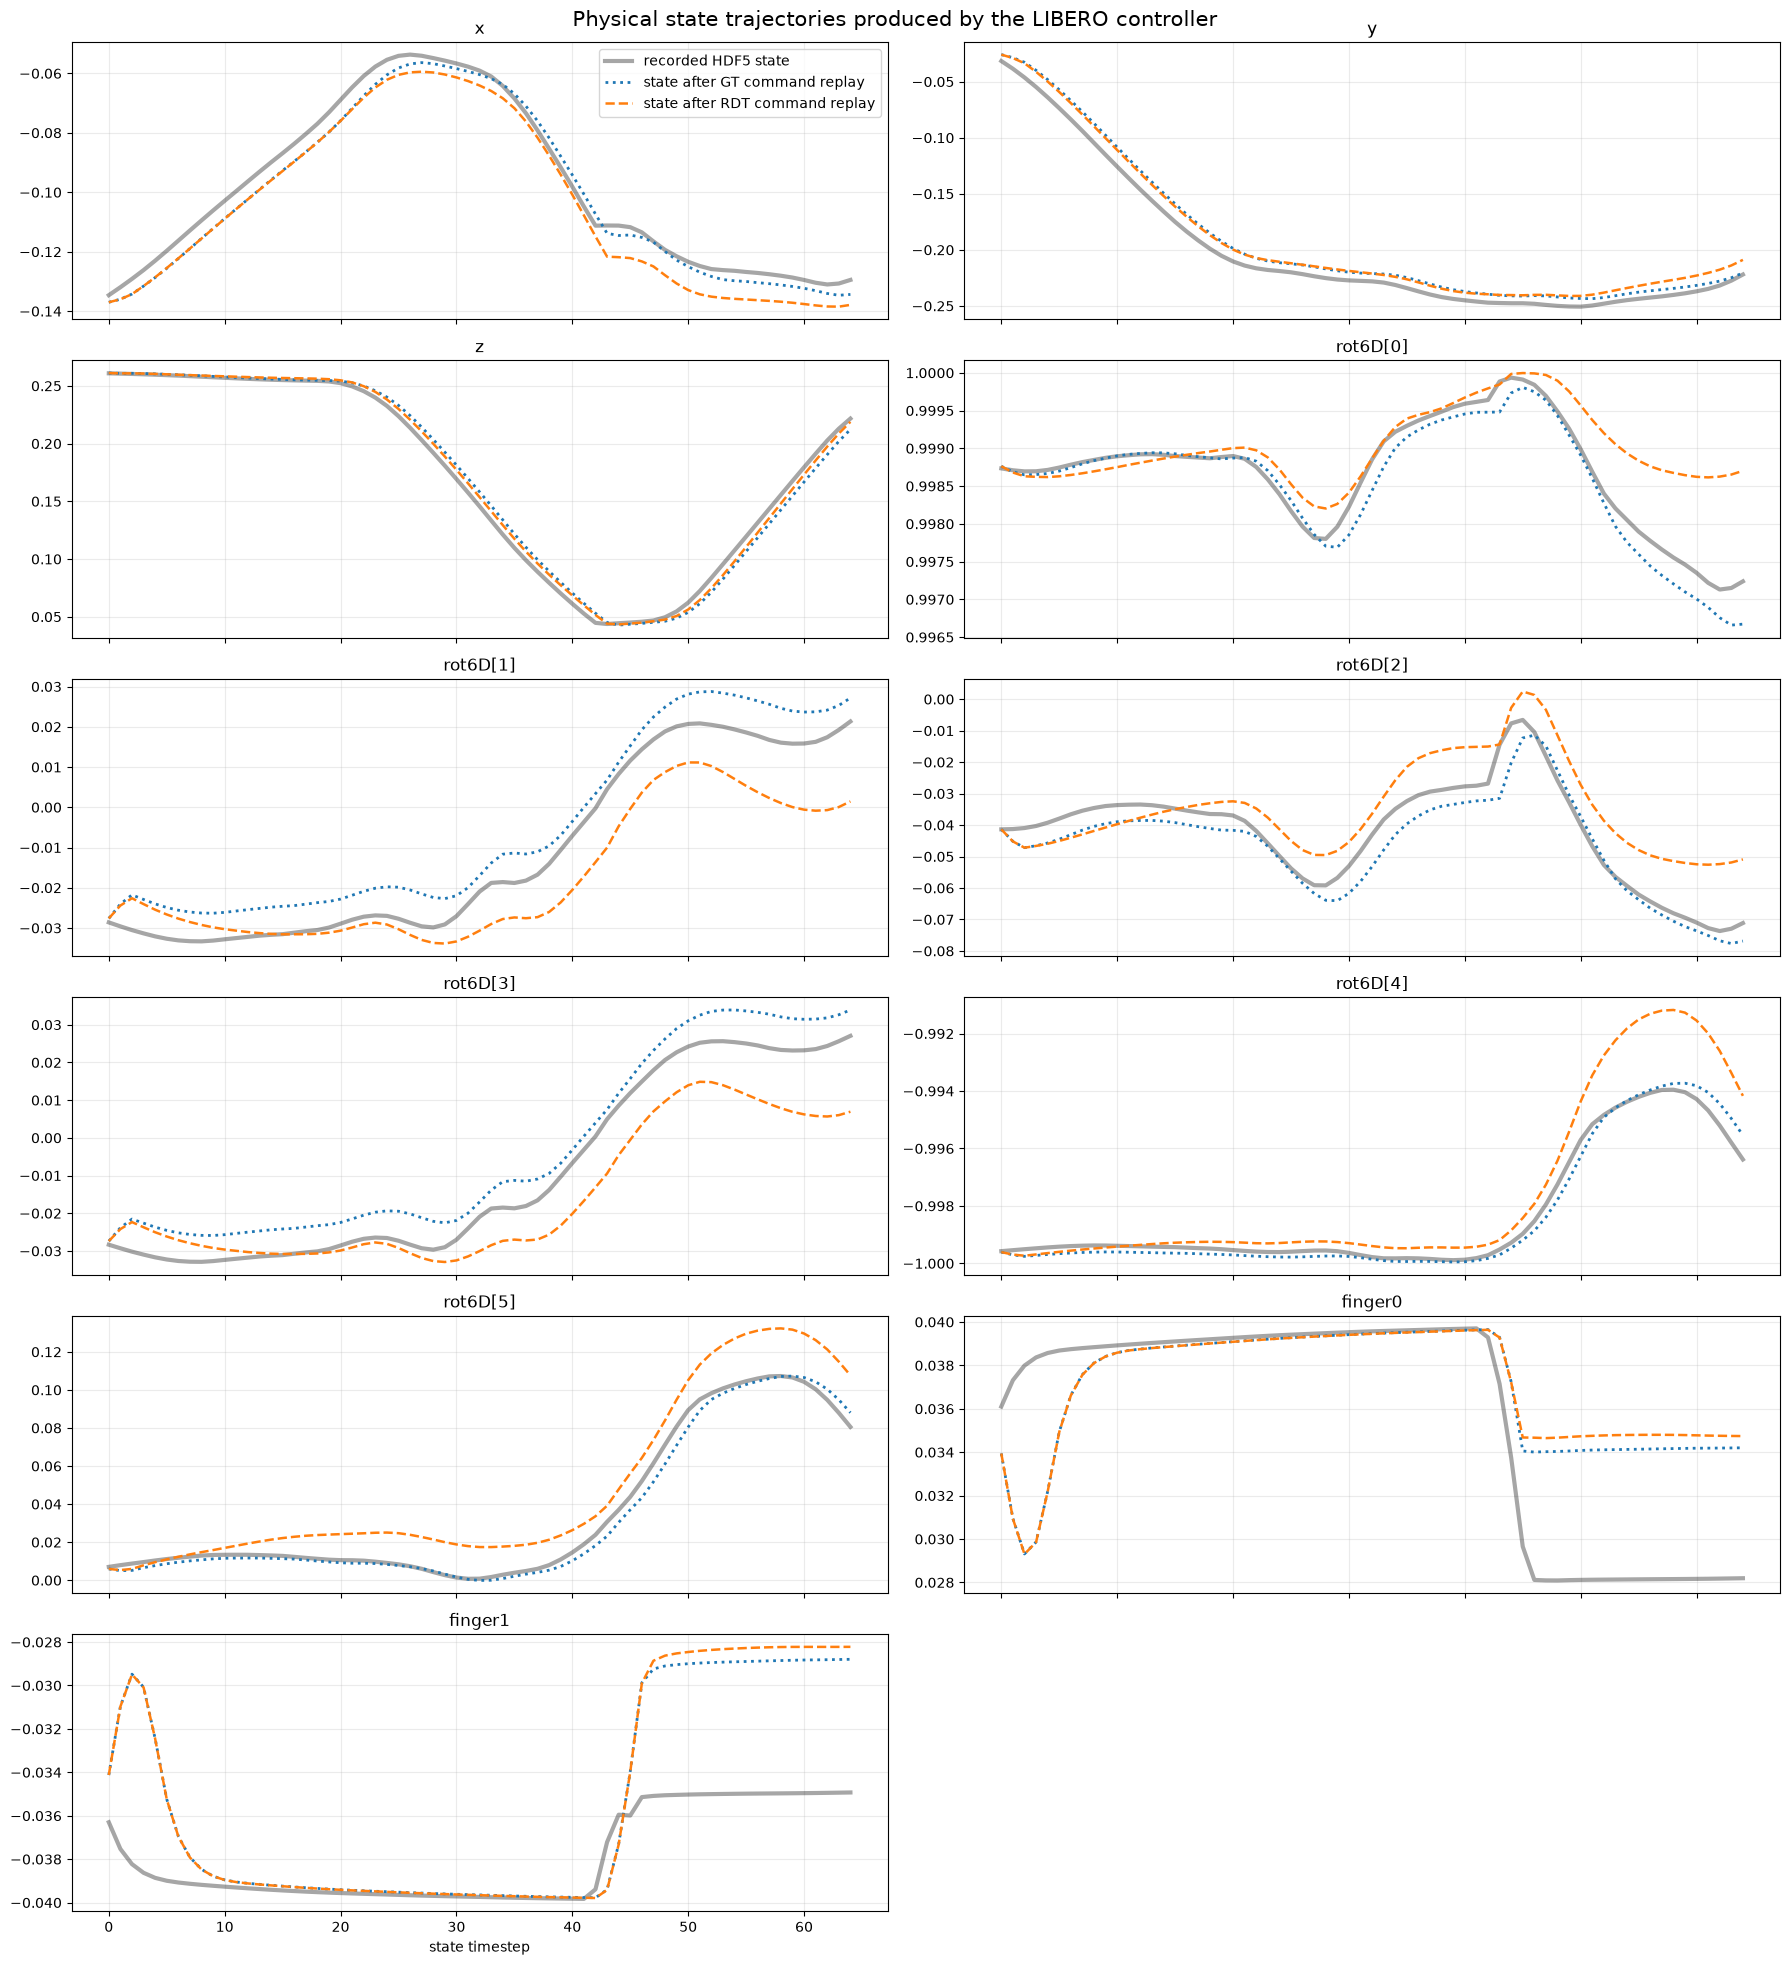

In [31]:
if not RUN_CONTROLLER_REPLAY:
    raise RuntimeError('Run the controller replay section first')

ground_truth_states = ground_truth_replay['states'][:replay_length]
predicted_states = predicted_replay['states'][:replay_length]
recorded_reference = recorded_reference[:replay_length]
state_steps = anchor_step + np.arange(replay_length)
state_names = ['x', 'y', 'z', 'rot6D[0]', 'rot6D[1]', 'rot6D[2]', 'rot6D[3]', 'rot6D[4]', 'rot6D[5]', 'finger0', 'finger1']

fig, axes = plt.subplots(6, 2, figsize=(18, 20), sharex=True)
axes = axes.ravel()
for dim, name in enumerate(state_names):
    axes[dim].plot(state_steps, recorded_reference[:, dim], color='black', linewidth=3.0, alpha=0.35, label='recorded HDF5 state')
    axes[dim].plot(state_steps, ground_truth_states[:, dim], color='tab:blue', linestyle=':', linewidth=2.0, label='state after GT command replay')
    axes[dim].plot(state_steps, predicted_states[:, dim], color='tab:orange', linestyle='--', linewidth=1.8, label='state after RDT command replay')
    axes[dim].set_title(name); axes[dim].grid(alpha=0.25)
    if dim == 0: axes[dim].legend()
axes[-1].axis('off')
for ax in axes[-2:]: ax.set_xlabel('state timestep')
fig.suptitle('Physical state trajectories produced by the LIBERO controller', fontsize=15)
plt.tight_layout()

{'RDT_vs_GT_position_mean_m': 0.005738971754908562,
 'RDT_vs_GT_position_max_m': 0.013861001469194889,
 'RDT_vs_GT_position_final_m': 0.013861001469194889,
 'RDT_vs_GT_orientation_mean_rad': 0.02305060625076294,
 'RDT_vs_GT_orientation_max_rad': 0.04073261469602585,
 'RDT_vs_GT_finger_mean': 0.00026316827279515564,
 'GT_replay_vs_HDF5_position_mean_m': 0.013781462796032429,
 'GT_replay_vs_HDF5_position_max_m': 0.018508033826947212}

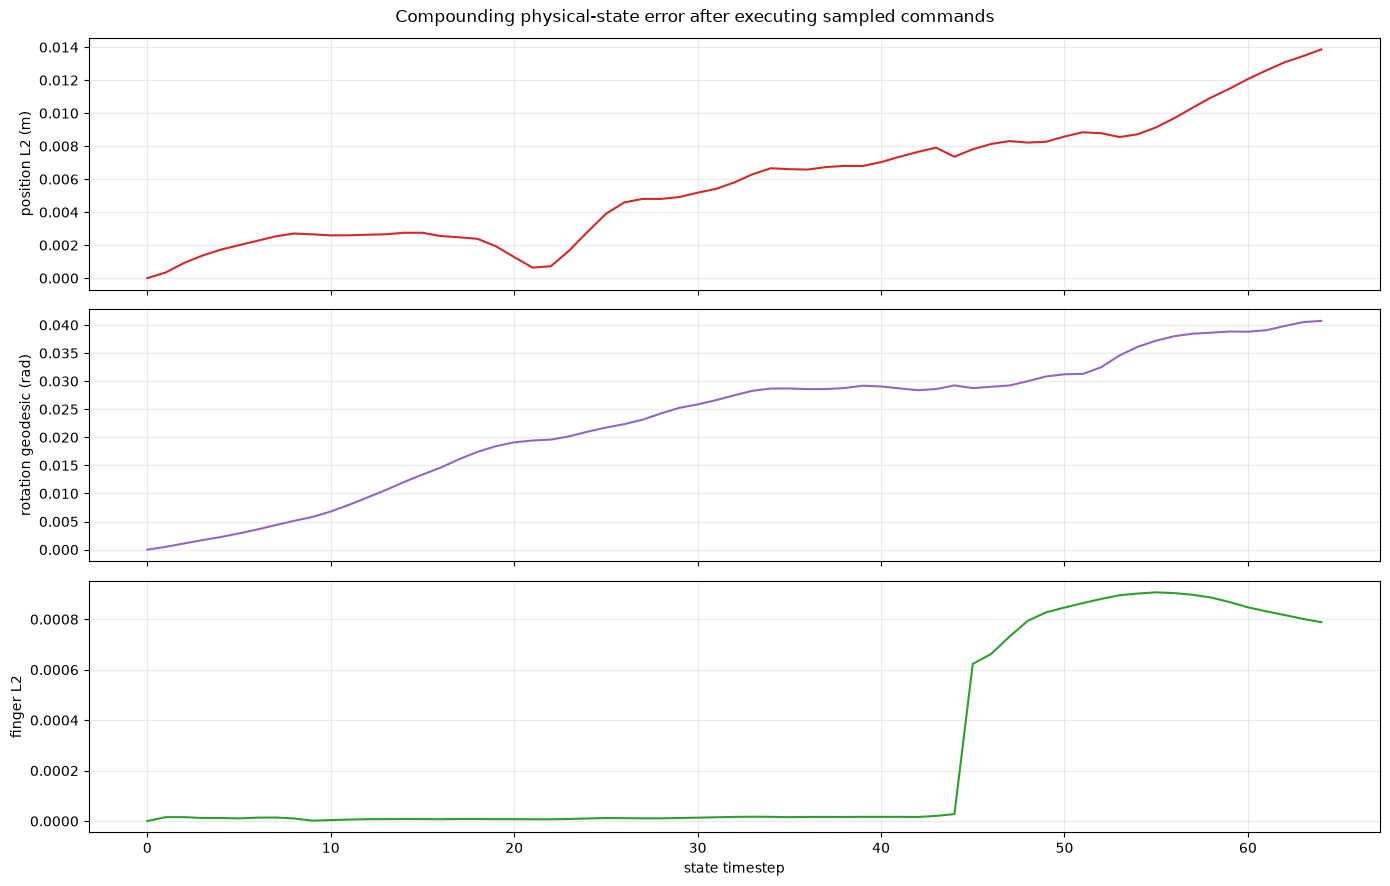

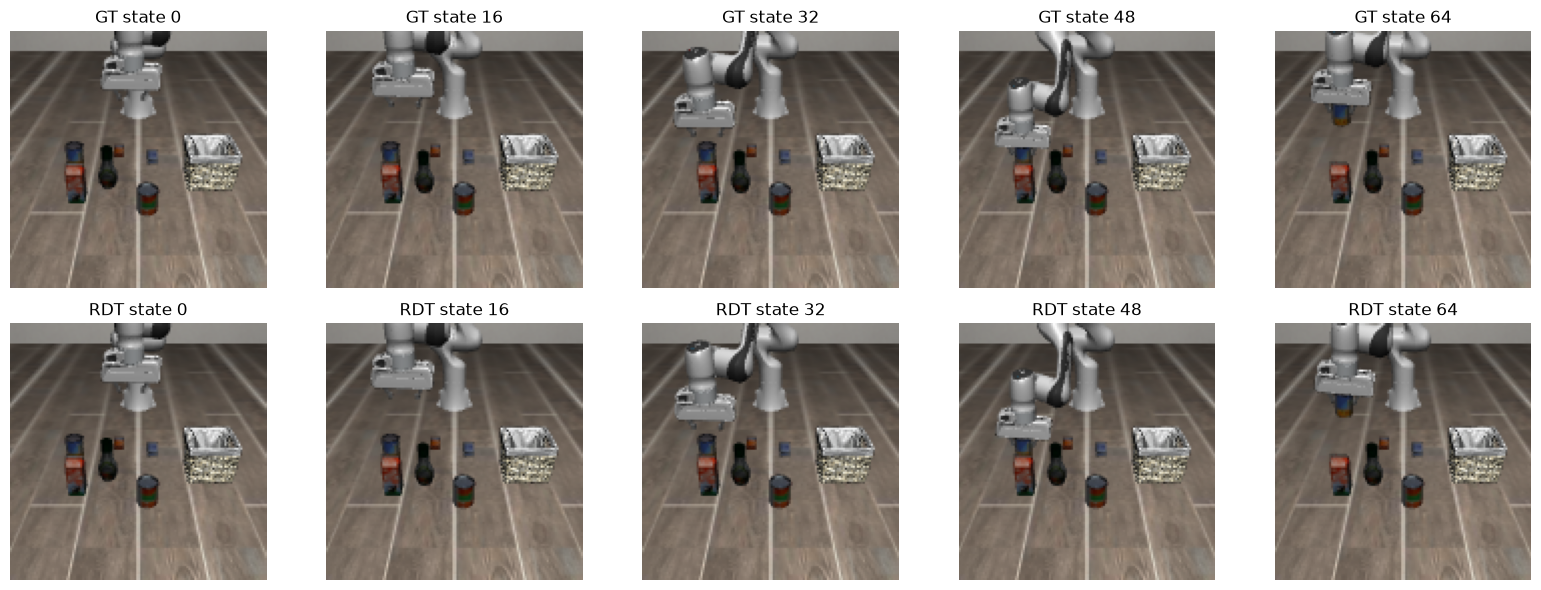

In [32]:
def rotation_geodesic_error(rotation6d_a, rotation6d_b):
    matrix_a = ortho6d_to_rotation_matrix(rotation6d_a)
    matrix_b = ortho6d_to_rotation_matrix(rotation6d_b)
    relative = np.swapaxes(matrix_a, -1, -2) @ matrix_b
    cosine = np.clip((np.trace(relative, axis1=-2, axis2=-1) - 1.0) / 2.0, -1.0, 1.0)
    return np.arccos(cosine)

position_error = np.linalg.norm(predicted_states[:, :3] - ground_truth_states[:, :3], axis=-1)
orientation_error = rotation_geodesic_error(predicted_states[:, 3:9], ground_truth_states[:, 3:9])
finger_error = np.linalg.norm(predicted_states[:, 9:11] - ground_truth_states[:, 9:11], axis=-1)
replay_control_error = np.linalg.norm(ground_truth_states[:, :3] - recorded_reference[:, :3], axis=-1)

display({
    'RDT_vs_GT_position_mean_m': float(position_error.mean()),
    'RDT_vs_GT_position_max_m': float(position_error.max()),
    'RDT_vs_GT_position_final_m': float(position_error[-1]),
    'RDT_vs_GT_orientation_mean_rad': float(orientation_error.mean()),
    'RDT_vs_GT_orientation_max_rad': float(orientation_error.max()),
    'RDT_vs_GT_finger_mean': float(finger_error.mean()),
    'GT_replay_vs_HDF5_position_mean_m': float(replay_control_error.mean()),
    'GT_replay_vs_HDF5_position_max_m': float(replay_control_error.max()),
})

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].plot(state_steps, position_error, color='tab:red'); axes[0].set_ylabel('position L2 (m)')
axes[1].plot(state_steps, orientation_error, color='tab:purple'); axes[1].set_ylabel('rotation geodesic (rad)')
axes[2].plot(state_steps, finger_error, color='tab:green'); axes[2].set_ylabel('finger L2'); axes[2].set_xlabel('state timestep')
for ax in axes: ax.grid(alpha=0.25)
fig.suptitle('Compounding physical-state error after executing sampled commands')
plt.tight_layout()

frame_indices = np.linspace(0, replay_length - 1, min(5, replay_length), dtype=int)
fig, axes = plt.subplots(2, len(frame_indices), figsize=(3.2 * len(frame_indices), 6), squeeze=False)
for col, index in enumerate(frame_indices):
    axes[0, col].imshow(ground_truth_replay['frames'][index]); axes[0, col].set_title(f'GT state {state_steps[index]}'); axes[0, col].axis('off')
    axes[1, col].imshow(predicted_replay['frames'][index]); axes[1, col].set_title(f'RDT state {state_steps[index]}'); axes[1, col].axis('off')
plt.tight_layout()

## 7. How to interpret the result

The existing failed rollout saved only episode-level success metadata, not its 600 executed commands or observations. Therefore that exact failed trajectory cannot be reconstructed retrospectively. This notebook instead performs a controlled replay of the real diffusion samples saved during overfitting.

- If the blue ground-truth replay disagrees with the black HDF5 reference, fix simulator initialization/controller reproducibility before judging RDT.
- If commands look close but the orange physical trajectory diverges, small command errors are compounding through the OSC controller and contacts.
- If this saved 64-action trajectory tracks well but the official rollout fails, the dominant problem is re-inference on unseen closed-loop observations. The overfit run trained only demo-0 timesteps 0–7, not the complete demonstration or both official initial states.
- A meaningful closed-loop memorization test should cache and overfit every timestep of at least one complete successful demonstration, then evaluate from that exact demonstration simulator state.

## 8. Trace clean x0 gripper predictions through all five diffusion calls

This section loads the final overfit artifact and one **release-containing cached condition**. It records three distinct quantities that should not be confused:

- **clean x0**: the model's direct 10D clean-action prediction at each denoising call;
- **solver state**: DPM-Solver's continuously integrated action trajectory after each call;
- **returned action**: continuous solver motion with gripper dimension 9 replaced by the final clean x0 value.

The ground truth is the cached 10D target for the exact same teacher-forced image/state condition. This diagnoses the policy on demonstrated observations; it does not claim that an off-policy rollout observation has the same ground-truth future.

In [33]:
from thinkflow_rdt.data import CachedFeatureDataset, ONLINE_SIGLIP_REQUIRED_KEYS

X0_OVERFIT_ROOT = REPO_ROOT / 'outputs/libero_object_task0_10demo_overfit_gripper_x0_decode'
X0_REPORT_PATH = X0_OVERFIT_ROOT / 'report.json'
X0_ARTIFACT = X0_OVERFIT_ROOT / 'artifact'
X0_BASE_ARTIFACT = REPO_ROOT / 'oxe_b0_merged_for_libero'
X0_CONFIG_PATH = REPO_ROOT / 'configs/b0_rdt1b_lora.yaml'
X0_SAMPLE_LOCAL_INDEX = None  # Set an integer to override automatic release-window selection.
X0_MAX_RELEASE_OFFSET = 16
X0_SEED = 42

assert X0_REPORT_PATH.exists(), X0_REPORT_PATH
assert (X0_ARTIFACT / 'interfaces.pt').exists(), X0_ARTIFACT
assert (X0_BASE_ARTIFACT / 'rdt_full.pt').exists(), X0_BASE_ARTIFACT

x0_report = json.loads(X0_REPORT_PATH.read_text(encoding='utf-8'))
x0_manifest = Path(x0_report['manifest'])
if not x0_manifest.is_absolute():
    x0_manifest = REPO_ROOT / x0_manifest
x0_dataset = CachedFeatureDataset(
    x0_manifest,
    required_keys=ONLINE_SIGLIP_REQUIRED_KEYS,
)
x0_dataset_indices = [int(index) for index in x0_report['configuration']['sample_indices']]

def cached_release_transition(sample):
    actions = torch.as_tensor(sample['actions'])
    valid = torch.as_tensor(sample['action_time_mask'], dtype=torch.bool)
    gripper = actions[valid, 9].float().numpy()
    transitions = np.flatnonzero((gripper[:-1] >= 0.0) & (gripper[1:] < 0.0)) + 1
    return (None if not len(transitions) else int(transitions[-1])), gripper

if X0_SAMPLE_LOCAL_INDEX is None:
    selected = None
    for local_index, dataset_index in enumerate(x0_dataset_indices):
        candidate = x0_dataset[dataset_index]
        transition, _ = cached_release_transition(candidate)
        if transition is not None and 1 <= transition <= X0_MAX_RELEASE_OFFSET:
            selected = (local_index, dataset_index, candidate, transition)
            break
    if selected is None:
        raise RuntimeError(
            f'No release transition found within the first {X0_MAX_RELEASE_OFFSET} targets'
        )
    x0_local_index, x0_dataset_index, x0_cached_sample, x0_release_offset = selected
else:
    x0_local_index = int(X0_SAMPLE_LOCAL_INDEX)
    x0_dataset_index = x0_dataset_indices[x0_local_index]
    x0_cached_sample = x0_dataset[x0_dataset_index]
    x0_release_offset, _ = cached_release_transition(x0_cached_sample)
    if x0_release_offset is None:
        raise ValueError('The manually selected sample contains no final release transition')

print({
    'local_index': x0_local_index,
    'dataset_index': x0_dataset_index,
    'episode_id': x0_cached_sample['episode_id'],
    'step_idx': int(x0_cached_sample['step_idx']),
    'release_future_offset': x0_release_offset,
})

{'local_index': 400, 'dataset_index': 400, 'episode_id': 'pick_up_the_alphabet_soup_and_place_it_in_the_basket_demo:demo_0', 'step_idx': 112, 'release_future_offset': 16}


In [34]:
from thinkflow_rdt.checkpoint import load_trainable_artifact
from thinkflow_rdt.config import load_config
from thinkflow_rdt.model import SFTConditionedRDT
from overfit_libero_cached import move_tensors, prepare_fixed_feature_batches

if not torch.cuda.is_available():
    raise RuntimeError('CUDA is required to load and trace RDT-1B')
x0_device = torch.device('cuda')
x0_cfg = load_config(X0_CONFIG_PATH)
x0_cache_metadata_path = x0_manifest.parent.parent / 'precompute_metadata.json'
x0_cache_metadata = json.loads(x0_cache_metadata_path.read_text(encoding='utf-8'))
x0_siglip_model_id = x0_cache_metadata.get(
    'siglip_model_id',
    'google/siglip-so400m-patch14-384',
)

# Encode this sample's lossless cached images once, then release SigLIP before RDT-1B.
x0_fixed_batches = prepare_fixed_feature_batches(
    [x0_cached_sample],
    cfg=x0_cfg,
    batch_size=1,
    device=x0_device,
    siglip_model_id=x0_siglip_model_id,
    siglip_fallback_model_id='google/siglip-so400m-patch14-384',
)
x0_cpu_batch = x0_fixed_batches[0]
x0_policy_batch = move_tensors(x0_cpu_batch, x0_device)

x0_model = SFTConditionedRDT(
    x0_cfg,
    load_pretrained=True,
    base_artifact=str(X0_BASE_ARTIFACT),
)
load_trainable_artifact(x0_model, X0_ARTIFACT, trainable=False)
x0_model.to(x0_device).eval()

artifact_metadata = json.loads(
    (X0_ARTIFACT / 'metadata.json').read_text(encoding='utf-8')
)
assert x0_model.mask_noisy_gripper_input is True
print({
    'artifact': str(X0_ARTIFACT),
    'mask_noisy_gripper_input': x0_model.mask_noisy_gripper_input,
    'artifact_mask_setting': artifact_metadata.get('mask_noisy_gripper_input'),
    'inference_steps': x0_model.runner.num_inference_timesteps,
    'siglip_model_id': x0_siglip_model_id,
})

/home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 448/448 [00:01<00:00, 287.06it/s]
[transformers] SiglipVisionModel LOAD REPORT from: google/siglip-so400m-patch14-384
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...26}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder

Diffusion params: 1.217850e+09
Diffusion params: 1.228320e+09
{'artifact': '/home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_object_task0_10demo_overfit_gripper_x0_decode/artifact', 'mask_noisy_gripper_input': True, 'artifact_mask_setting': True, 'inference_steps': 5, 'siglip_model_id': 'google/siglip-so400m-patch14-384'}


In [35]:
# Trace the exact normal sample_actions() path without changing its output.
x0_clean_trace = []
x0_solver_trace = []
x0_scheduler = x0_model.runner.noise_scheduler_sample
x0_original_scheduler_step = x0_scheduler.step

def capture_clean_x0(_module, _inputs, output):
    x0_clean_trace.append(output.detach().float().cpu())

def capture_solver_step(*args, **kwargs):
    result = x0_original_scheduler_step(*args, **kwargs)
    x0_solver_trace.append(result.prev_sample.detach().float().cpu())
    return result

x0_forward_hook = x0_model.runner.model.register_forward_hook(capture_clean_x0)
x0_scheduler.step = capture_solver_step
torch.manual_seed(X0_SEED)
torch.cuda.manual_seed_all(X0_SEED)
try:
    with torch.inference_mode():
        x0_returned_10d = x0_model.sample_actions(x0_policy_batch).float().cpu()
finally:
    x0_forward_hook.remove()
    x0_scheduler.step = x0_original_scheduler_step

x0_timesteps = x0_scheduler.timesteps.detach().cpu().numpy().astype(int)
x0_clean_trace = torch.stack(x0_clean_trace)[:, 0]   # [inference step, horizon, 10]
x0_solver_trace = torch.stack(x0_solver_trace)[:, 0] # [inference step, horizon, 10]
x0_returned_10d = x0_returned_10d[0]

x0_valid_mask = x0_cpu_batch['action_time_mask'][0].bool()
x0_valid_count = int(x0_valid_mask.sum())
x0_target_10d = x0_cpu_batch['actions'][0, :x0_valid_count].float()
x0_clean_trace = x0_clean_trace[:, :x0_valid_count]
x0_solver_trace = x0_solver_trace[:, :x0_valid_count]
x0_returned_10d = x0_returned_10d[:x0_valid_count]

assert len(x0_timesteps) == len(x0_clean_trace) == len(x0_solver_trace)
torch.testing.assert_close(
    x0_returned_10d[:, 9],
    x0_clean_trace[-1, :, 9],
)
print('DPM-Solver timesteps:', x0_timesteps.tolist())
print('Valid target commands:', x0_valid_count)
print('Returned gripper equals final clean x0: yes')

DPM-Solver timesteps: [999, 799, 599, 400, 200]
Valid target commands: 36
Returned gripper equals final clean x0: yes


In [36]:
x0_offsets = np.arange(x0_valid_count)
x0_ground_truth_gripper = x0_target_10d[:, 9].numpy()
x0_clean_gripper = x0_clean_trace[:, :, 9].numpy()
x0_solver_gripper = x0_solver_trace[:, :, 9].numpy()
x0_returned_gripper = x0_returned_10d[:, 9].numpy()

x0_release_mask = (
    (x0_offsets >= x0_release_offset)
    & (x0_ground_truth_gripper < 0.0)
)
x0_hold_mask = x0_ground_truth_gripper >= 0.0
x0_approach_mask = (x0_ground_truth_gripper < 0.0) & ~x0_release_mask

def gripper_phase_metrics(name, prediction):
    predicted_positive = np.asarray(prediction) >= 0.0
    target_positive = x0_ground_truth_gripper >= 0.0
    row = {
        'prediction': name,
        'overall_accuracy': float(np.mean(predicted_positive == target_positive)),
        'RMSE': float(np.sqrt(np.mean((prediction - x0_ground_truth_gripper) ** 2))),
    }
    for phase, mask in (
        ('approach_open', x0_approach_mask),
        ('close_hold', x0_hold_mask),
        ('release_open', x0_release_mask),
    ):
        row[f'{phase}_accuracy'] = (
            None if not mask.any()
            else float(np.mean(predicted_positive[mask] == target_positive[mask]))
        )
        row[f'{phase}_commands'] = int(mask.sum())
    return row

x0_metric_rows = [
    gripper_phase_metrics(f'clean_x0@t{timestep}', prediction)
    for timestep, prediction in zip(x0_timesteps, x0_clean_gripper)
]
x0_metric_rows.extend([
    gripper_phase_metrics('old_DPM_solver_gripper', x0_solver_gripper[-1]),
    gripper_phase_metrics('returned_final_x0_gripper', x0_returned_gripper),
])
display(x0_metric_rows)

window_start = max(0, x0_release_offset - 8)
window_stop = min(x0_valid_count, x0_release_offset + 9)
release_rows = []
for offset in range(window_start, window_stop):
    row = {
        'future_offset': offset,
        'demo_action_step': int(x0_cached_sample['step_idx']) + offset,
        'ground_truth': float(x0_ground_truth_gripper[offset]),
    }
    for timestep_index, timestep in enumerate(x0_timesteps):
        row[f'x0_t{timestep}'] = float(x0_clean_gripper[timestep_index, offset])
    row['old_solver_final'] = float(x0_solver_gripper[-1, offset])
    row['returned_gripper'] = float(x0_returned_gripper[offset])
    release_rows.append(row)
display(release_rows)

[{'prediction': 'clean_x0@t999',
  'overall_accuracy': 0.4444444444444444,
  'RMSE': 1.4219660758972168,
  'approach_open_accuracy': None,
  'approach_open_commands': 0,
  'close_hold_accuracy': 1.0,
  'close_hold_commands': 16,
  'release_open_accuracy': 0.0,
  'release_open_commands': 20},
 {'prediction': 'clean_x0@t799',
  'overall_accuracy': 0.4444444444444444,
  'RMSE': 1.4346396923065186,
  'approach_open_accuracy': None,
  'approach_open_commands': 0,
  'close_hold_accuracy': 1.0,
  'close_hold_commands': 16,
  'release_open_accuracy': 0.0,
  'release_open_commands': 20},
 {'prediction': 'clean_x0@t599',
  'overall_accuracy': 0.4444444444444444,
  'RMSE': 1.4494152069091797,
  'approach_open_accuracy': None,
  'approach_open_commands': 0,
  'close_hold_accuracy': 1.0,
  'close_hold_commands': 16,
  'release_open_accuracy': 0.0,
  'release_open_commands': 20},
 {'prediction': 'clean_x0@t400',
  'overall_accuracy': 0.4444444444444444,
  'RMSE': 1.45687997341156,
  'approach_open_a

[{'future_offset': 8,
  'demo_action_step': 120,
  'ground_truth': 1.0,
  'x0_t999': 1.0234375,
  'x0_t799': 1.03125,
  'x0_t599': 1.0234375,
  'x0_t400': 0.9921875,
  'x0_t200': 0.96875,
  'old_solver_final': 0.96875,
  'returned_gripper': 0.96875},
 {'future_offset': 9,
  'demo_action_step': 121,
  'ground_truth': 1.0,
  'x0_t999': 1.0234375,
  'x0_t799': 1.03125,
  'x0_t599': 1.0234375,
  'x0_t400': 1.0,
  'x0_t200': 0.9765625,
  'old_solver_final': 0.9765625,
  'returned_gripper': 0.9765625},
 {'future_offset': 10,
  'demo_action_step': 122,
  'ground_truth': 1.0,
  'x0_t999': 1.0390625,
  'x0_t799': 1.046875,
  'x0_t599': 1.0390625,
  'x0_t400': 1.0078125,
  'x0_t200': 0.97265625,
  'old_solver_final': 0.97265625,
  'returned_gripper': 0.97265625},
 {'future_offset': 11,
  'demo_action_step': 123,
  'ground_truth': 1.0,
  'x0_t999': 1.0390625,
  'x0_t799': 1.046875,
  'x0_t599': 1.03125,
  'x0_t400': 1.0078125,
  'x0_t200': 0.9765625,
  'old_solver_final': 0.9765625,
  'returned_g

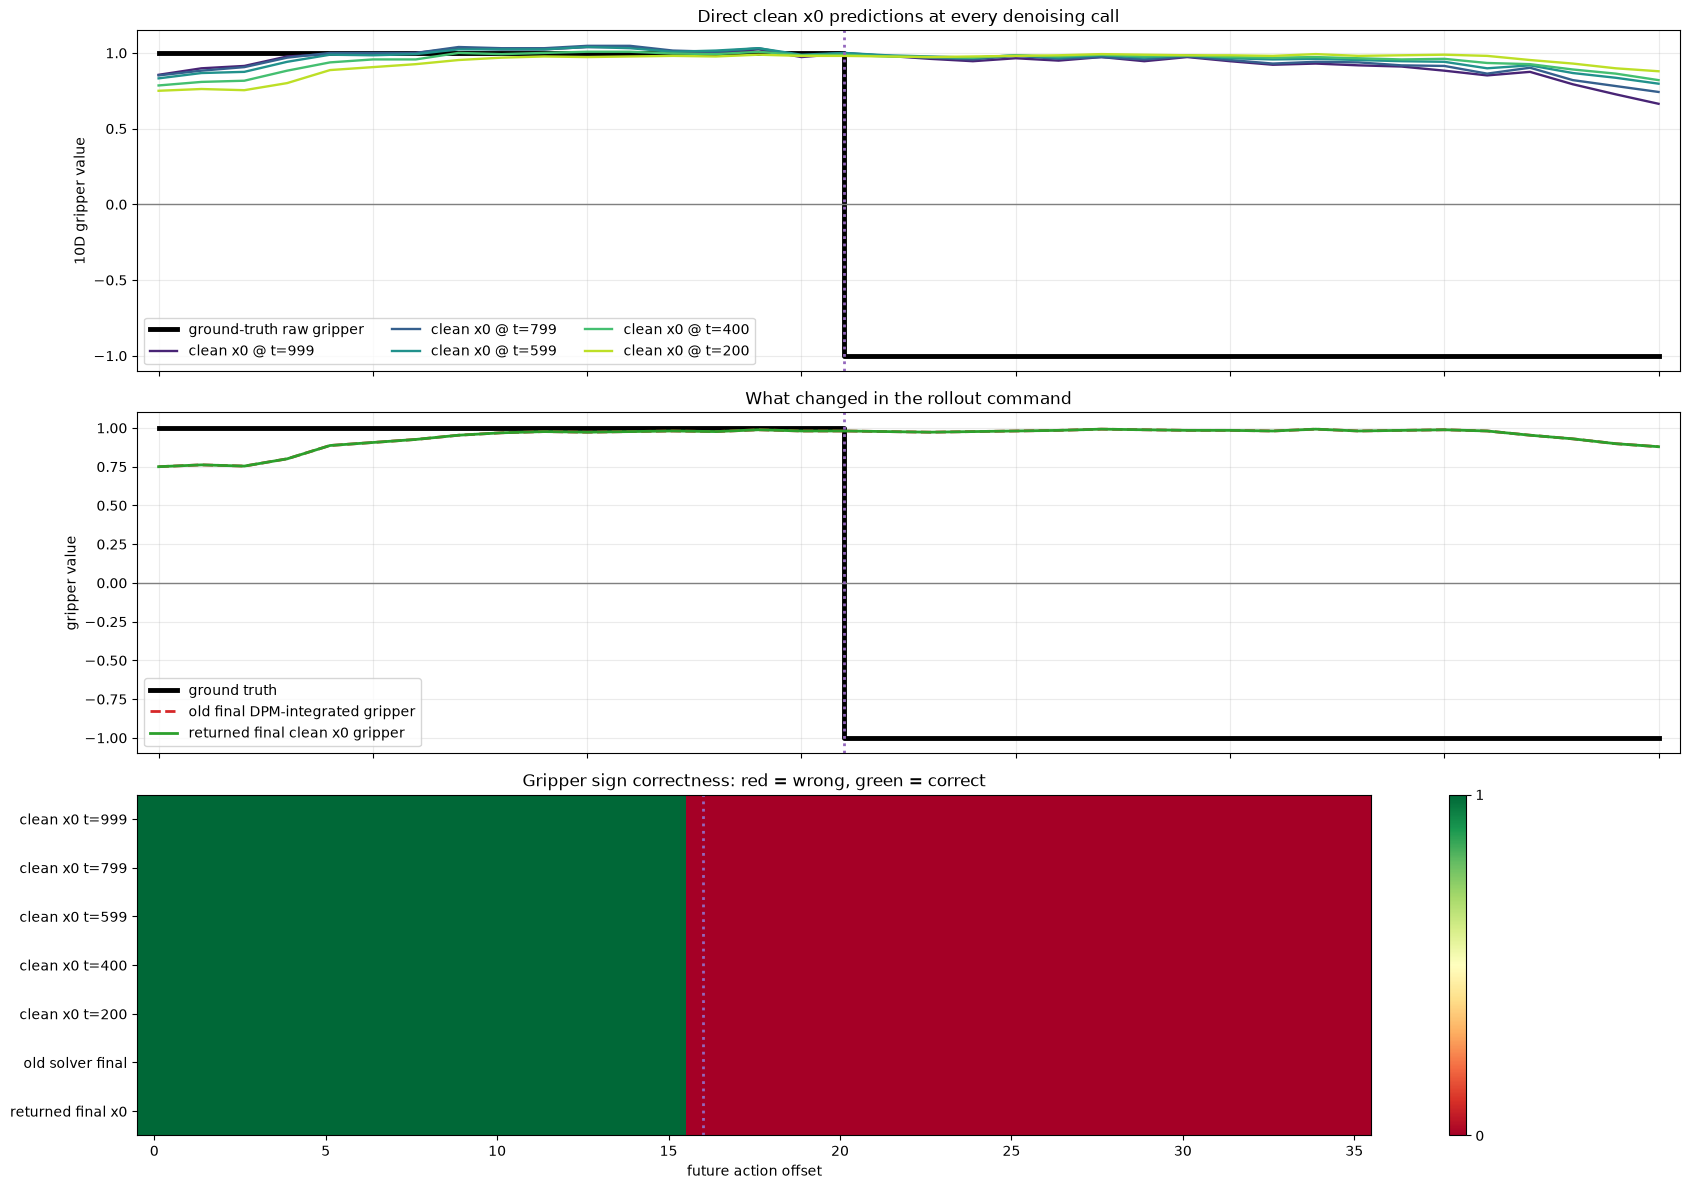

In [37]:
fig, axes = plt.subplots(3, 1, figsize=(17, 12), sharex=True)

axes[0].step(
    x0_offsets,
    x0_ground_truth_gripper,
    where='post',
    color='black',
    linewidth=3.5,
    label='ground-truth raw gripper',
)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(x0_timesteps)))
for color, timestep, prediction in zip(colors, x0_timesteps, x0_clean_gripper):
    axes[0].plot(
        x0_offsets,
        prediction,
        color=color,
        linewidth=1.7,
        label=f'clean x0 @ t={timestep}',
    )
axes[0].axhline(0.0, color='grey', linewidth=1)
axes[0].set_ylabel('10D gripper value')
axes[0].set_title('Direct clean x0 predictions at every denoising call')
axes[0].legend(ncol=3)
axes[0].grid(alpha=0.25)

axes[1].step(
    x0_offsets,
    x0_ground_truth_gripper,
    where='post',
    color='black',
    linewidth=3.5,
    label='ground truth',
)
axes[1].plot(
    x0_offsets,
    x0_solver_gripper[-1],
    color='tab:red',
    linestyle='--',
    linewidth=2,
    label='old final DPM-integrated gripper',
)
axes[1].plot(
    x0_offsets,
    x0_returned_gripper,
    color='tab:green',
    linewidth=2,
    label='returned final clean x0 gripper',
)
axes[1].axhline(0.0, color='grey', linewidth=1)
axes[1].set_ylabel('gripper value')
axes[1].set_title('What changed in the rollout command')
axes[1].legend()
axes[1].grid(alpha=0.25)

correctness = np.vstack([
    (x0_clean_gripper >= 0.0) == (x0_ground_truth_gripper[None] >= 0.0),
    ((x0_solver_gripper[-1] >= 0.0) == (x0_ground_truth_gripper >= 0.0))[None],
    ((x0_returned_gripper >= 0.0) == (x0_ground_truth_gripper >= 0.0))[None],
]).astype(float)
correctness_labels = [
    *(f'clean x0 t={timestep}' for timestep in x0_timesteps),
    'old solver final',
    'returned final x0',
]
image = axes[2].imshow(
    correctness,
    aspect='auto',
    interpolation='nearest',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
)
axes[2].set_yticks(np.arange(len(correctness_labels)), correctness_labels)
axes[2].set_xlabel('future action offset')
axes[2].set_title('Gripper sign correctness: red = wrong, green = correct')
plt.colorbar(image, ax=axes[2], ticks=[0, 1])

for ax in axes:
    ax.axvline(
        x0_release_offset,
        color='tab:purple',
        linestyle=':',
        linewidth=2,
        label='ground-truth release',
    )
plt.tight_layout()

In [38]:
# Confirm the complete decoded LIBERO command, not only model dimension 9.
x0_target_7d = rdt_action_to_libero(x0_target_10d.numpy())
x0_returned_7d = rdt_action_to_libero(x0_returned_10d.numpy())
x0_old_solver_7d = rdt_action_to_libero(x0_solver_trace[-1].numpy())

display({
    'returned_motion_RMSE_6d': float(
        np.sqrt(np.mean((x0_returned_7d[:, :6] - x0_target_7d[:, :6]) ** 2))
    ),
    'returned_gripper_accuracy': float(
        np.mean((x0_returned_7d[:, 6] >= 0.0) == (x0_target_7d[:, 6] >= 0.0))
    ),
    'returned_release_accuracy': float(
        np.mean(
            (x0_returned_7d[x0_release_mask, 6] >= 0.0)
            == (x0_target_7d[x0_release_mask, 6] >= 0.0)
        )
    ),
    'old_solver_release_accuracy': float(
        np.mean(
            (x0_old_solver_7d[x0_release_mask, 6] >= 0.0)
            == (x0_target_7d[x0_release_mask, 6] >= 0.0)
        )
    ),
})

print(
    'Important: perfect cached-condition gripper accuracy only proves that the '
    'teacher-forced clean x0 is correct. A closed-loop rollout can still release '
    'at the wrong physical location after its motion/state trajectory departs '
    'from the demonstration.'
)

{'returned_motion_RMSE_6d': 0.2344261258840561,
 'returned_gripper_accuracy': 0.4444444444444444,
 'returned_release_accuracy': 0.0,
 'old_solver_release_accuracy': 0.0}

Important: perfect cached-condition gripper accuracy only proves that the teacher-forced clean x0 is correct. A closed-loop rollout can still release at the wrong physical location after its motion/state trajectory departs from the demonstration.


### Reading these plots

- If every clean-x0 row is green but the old solver row is red, the network learned gripper and continuous solver integration was the problem.
- If the returned-final-x0 row is green, the command sent by the current rollout code has the correct sign **for this cached demonstrated condition**.
- If clean x0 becomes wrong specifically at high noise, the conditional diffusion model has not learned the phase independently of the noisy action input.
- If cached-condition x0 is correct but the online rollout releases in the wrong location, inspect motion and online observations. The rollout has entered a state that is no longer aligned with the demonstration, so its teacher-forced future is not a valid ground-truth comparison.

## 9. Live RDT inference: re-plan every four commands

This runs the production rollout path using the exact 10-demo artifact and merged OXE base. It starts from `demo_0`, samples a new 64-command plan every four environment steps, and logs each executed command and resulting physical 11D state. It is independent of the saved `predicted_commands` variable above.

In [45]:
import subprocess

LIVE_ARTIFACT = REPO_ROOT / 'outputs/libero_object_task0_10demo_overfit/artifact'
LIVE_BASE = REPO_ROOT / 'oxe_b0_merged_for_libero'
LIVE_CACHE = REPO_ROOT / 'cache_features_libero_object_task0_10demos'
LIVE_DEMO = REPO_ROOT / 'libero-dataset/libero_object/pick_up_the_alphabet_soup_and_place_it_in_the_basket_demo.hdf5'
LIVE_DEMO_NAME = 'demo_0'
LIVE_DIR = REPO_ROOT / 'outputs/libero_object_task0_10demo_overfit/notebook_chunk4_analysis'
LIVE_VIDEO = LIVE_DIR / f'{LIVE_DEMO_NAME}_chunk4.mp4'
LIVE_TRACE = LIVE_DIR / f'{LIVE_DEMO_NAME}_chunk4_actions.jsonl'
LIVE_OBSERVATIONS = LIVE_DIR / f'{LIVE_DEMO_NAME}_chunk4_observations.npz'
LIVE_RERUN = True  # Change to False to reuse the existing trace.

for path in (LIVE_ARTIFACT, LIVE_BASE, LIVE_CACHE, LIVE_DEMO):
    assert path.exists(), path
LIVE_MAX_STEPS = 200
LIVE_DIR.mkdir(parents=True, exist_ok=True)
live_command = [
    sys.executable, str(REPO_ROOT / 'scripts/rollout_libero_rdt.py'),
    '--config', str(REPO_ROOT / 'configs/b0_rdt1b_lora.yaml'),
    '--benchmark', 'libero_object', '--task-id', '0',
    '--checkpoint', str(LIVE_ARTIFACT), '--base-artifact', str(LIVE_BASE),
    '--cache-root', str(LIVE_CACHE),
    '--demo-hdf5', str(LIVE_DEMO), '--demo-name', LIVE_DEMO_NAME,
    '--action-chunk', '4', '--max-steps', str(LIVE_MAX_STEPS),
    '--seed', '42', '--qwen-refresh-every', '1', '--clean-x0-gripper',
    '--output', str(LIVE_VIDEO), '--action-debug-jsonl', str(LIVE_TRACE),
    '--observation-debug-npz', str(LIVE_OBSERVATIONS),
]
print(' '.join(live_command))
if LIVE_RERUN:
    subprocess.run(live_command, cwd=REPO_ROOT, check=True)
else:
    assert LIVE_TRACE.exists(), LIVE_TRACE
    assert LIVE_OBSERVATIONS.exists(), LIVE_OBSERVATIONS
print('Trace:', LIVE_TRACE)
print('Video:', LIVE_VIDEO)
print('Observations:', LIVE_OBSERVATIONS)

/home/ubuntu/ThinkFlow-RDT-1B/.venv/bin/python /home/ubuntu/ThinkFlow-RDT-1B/scripts/rollout_libero_rdt.py --config /home/ubuntu/ThinkFlow-RDT-1B/configs/b0_rdt1b_lora.yaml --benchmark libero_object --task-id 0 --checkpoint /home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_object_task0_10demo_overfit/artifact --base-artifact /home/ubuntu/ThinkFlow-RDT-1B/oxe_b0_merged_for_libero --cache-root /home/ubuntu/ThinkFlow-RDT-1B/cache_features_libero_object_task0_10demos --demo-hdf5 /home/ubuntu/ThinkFlow-RDT-1B/libero-dataset/libero_object/pick_up_the_alphabet_soup_and_place_it_in_the_basket_demo.hdf5 --demo-name demo_0 --action-chunk 4 --max-steps 200 --seed 42 --qwen-refresh-every 1 --clean-x0-gripper --output /home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_object_task0_10demo_overfit/notebook_chunk4_analysis/demo_0_chunk4.mp4 --action-debug-jsonl /home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_object_task0_10demo_overfit/notebook_chunk4_analysis/demo_0_chunk4_actions.jsonl --observation-debug-npz /ho

/home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (macros.py:55)
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional informa

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Loading T5, SigLIP, and optional Qwen encoders...


Loading weights: 100%|██████████| 220/220 [00:05<00:00, 39.73it/s]
[transformers] T5EncoderModel LOAD REPORT from: google/t5-v1_1-xxl
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] The tokenizer you are loading from 'model/model/stage1_unsloth' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
/home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/torch/jit/_script.py:362: DeprecationWarning: `torch.jit.script_method` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.war

Loading RDT artifact /home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_object_task0_10demo_overfit/artifact...
Diffusion params: 1.217850e+09
Diffusion params: 1.228320e+09
Gripper decoding: final clean x0
[Warning]: datasets path /home/ubuntu/ThinkFlow-RDT-1B/dataset/LIBERO/Object/datasets does not exist!
plan=1 simulator_step=4 success=False elapsed=4.8s
plan=2 simulator_step=8 success=False elapsed=7.3s
plan=3 simulator_step=12 success=False elapsed=9.5s
plan=4 simulator_step=16 success=False elapsed=11.5s
plan=5 simulator_step=20 success=False elapsed=13.6s
plan=6 simulator_step=24 success=False elapsed=15.9s
plan=7 simulator_step=28 success=False elapsed=18.1s
plan=8 simulator_step=32 success=False elapsed=20.5s
plan=9 simulator_step=36 success=False elapsed=22.6s
plan=10 simulator_step=40 success=False elapsed=24.8s
plan=11 simulator_step=44 success=False elapsed=26.8s
plan=12 simulator_step=48 success=False elapsed=28.9s
plan=13 simulator_step=52 success=False elapsed=31.3s
plan=14 s

In [46]:
live_rows = [json.loads(line) for line in LIVE_TRACE.read_text().splitlines() if line.strip()]
if not live_rows:
    raise ValueError(f'No replans recorded in {LIVE_TRACE}')
live_predicted_commands = np.concatenate([np.asarray(row['executed_libero_actions'], dtype=np.float32) for row in live_rows])
# State element zero is the chunk's initial state; subsequent elements are
# physical observations after each executed RDT command.
live_predicted_states = np.concatenate([np.asarray(row['observed_rdt_states'], dtype=np.float32)[1:] for row in live_rows])
with h5py.File(LIVE_DEMO, 'r') as handle:
    demo = handle['data'][LIVE_DEMO_NAME]
    live_actual_commands_all = np.asarray(demo['actions'], dtype=np.float32)[:, :7]
    obs = demo['obs']
    pos_key = 'ee_pos' if 'ee_pos' in obs else 'robot0_eef_pos'
    ori_key = 'ee_ori' if 'ee_ori' in obs else 'robot0_eef_quat'
    grip_key = 'gripper_states' if 'gripper_states' in obs else 'robot0_gripper_qpos'
    live_actual_states_all = np.concatenate([
        np.asarray(obs[pos_key], dtype=np.float32)[..., :3],
        libero_orientation_to_ortho6d(np.asarray(obs[ori_key])),
        np.asarray(obs[grip_key], dtype=np.float32)[..., :2],
    ], axis=-1)
live_length = min(len(live_predicted_commands), len(live_predicted_states), len(live_actual_commands_all), len(live_actual_states_all) - 1)
live_predicted_commands = live_predicted_commands[:live_length]
live_predicted_states = live_predicted_states[:live_length]
live_actual_commands = live_actual_commands_all[:live_length]
live_actual_states = live_actual_states_all[1:live_length + 1]
live_steps = np.arange(live_length)
display({
    'replans': len(live_rows), 'executed_steps': live_length,
    'command_RMSE_7d': float(np.sqrt(np.mean((live_predicted_commands - live_actual_commands) ** 2))),
    'gripper_sign_accuracy': float(np.mean((live_predicted_commands[:, 6] >= 0) == (live_actual_commands[:, 6] >= 0))),
})

{'replans': 50,
 'executed_steps': 147,
 'command_RMSE_7d': 0.36996713280677795,
 'gripper_sign_accuracy': 0.8299319727891157}

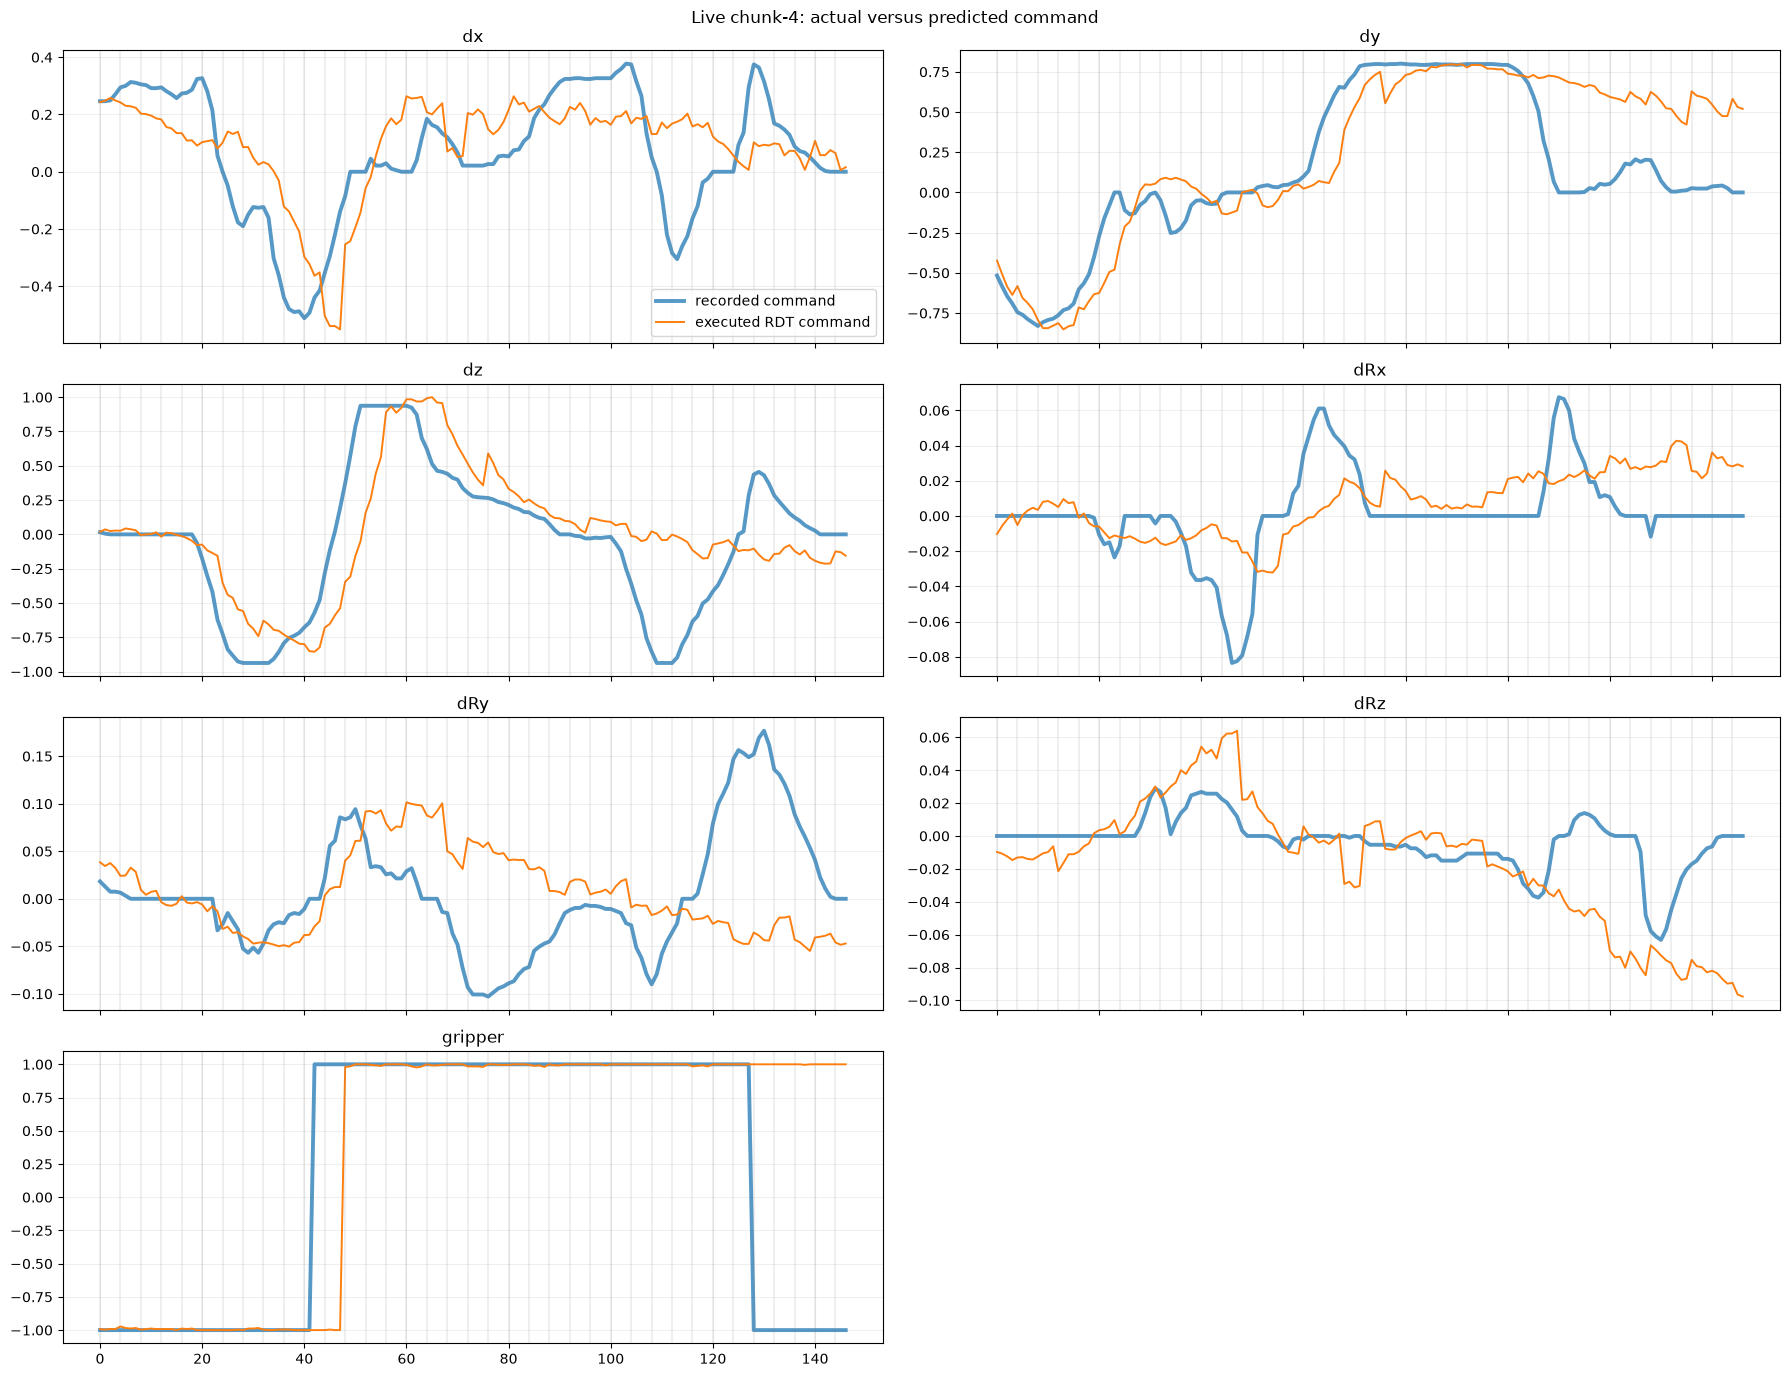

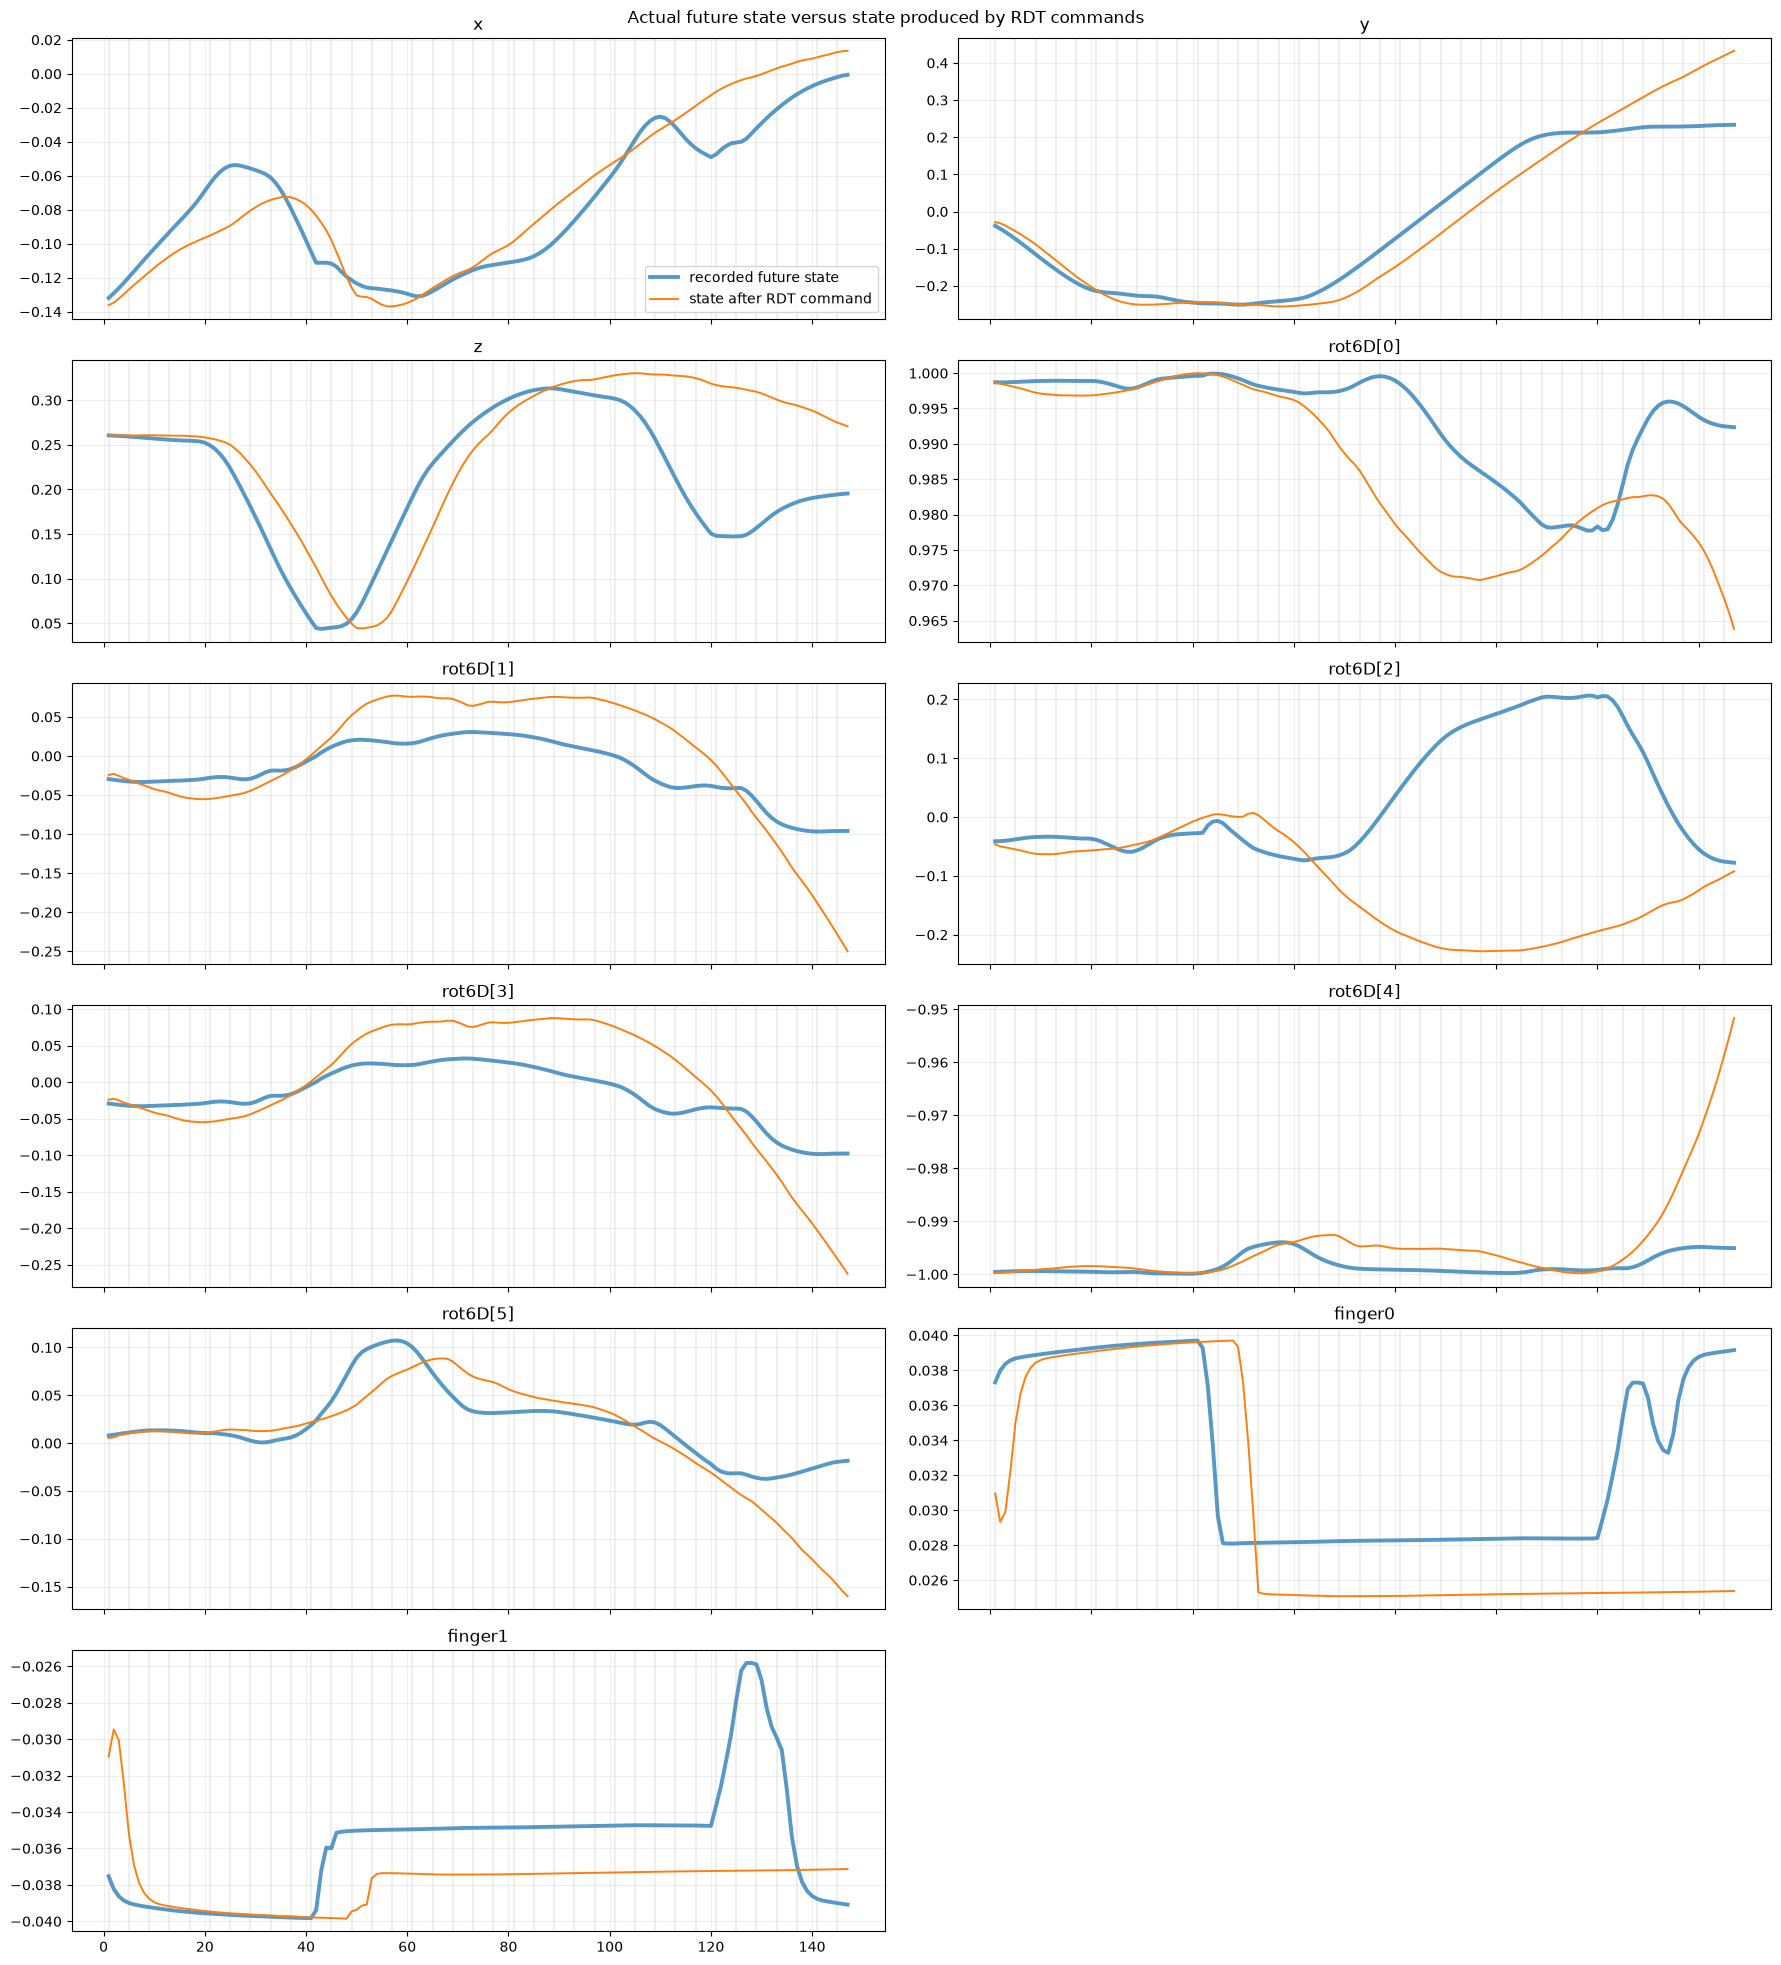

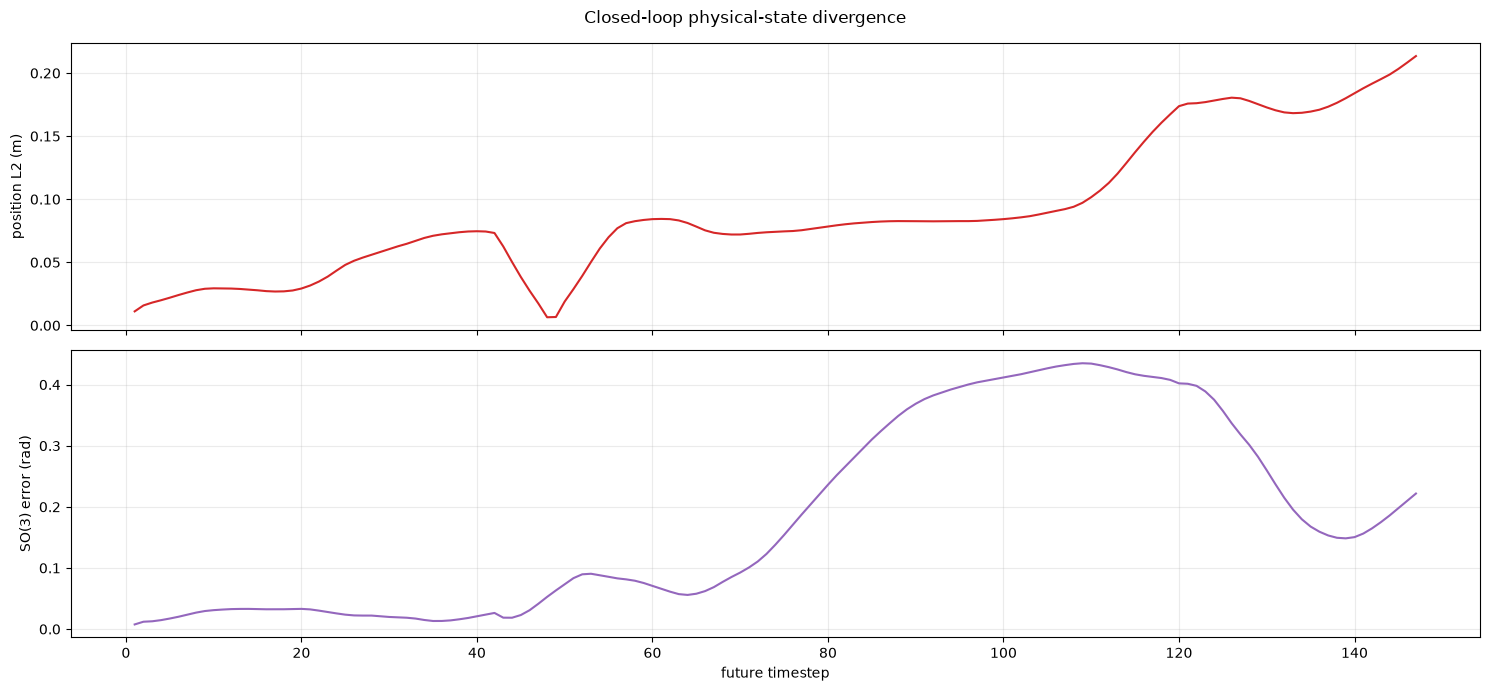

In [47]:
live_action_names = ['dx', 'dy', 'dz', 'dRx', 'dRy', 'dRz', 'gripper']
fig, axes = plt.subplots(4, 2, figsize=(18, 14), sharex=True); axes = axes.ravel()
for dim, name in enumerate(live_action_names):
    axes[dim].plot(live_steps, live_actual_commands[:, dim], color='tab:blue', linewidth=2.8, alpha=.75, label='recorded command')
    axes[dim].plot(live_steps, live_predicted_commands[:, dim], color='tab:orange', linewidth=1.4, label='executed RDT command')
    for boundary in range(0, live_length, 4): axes[dim].axvline(boundary, color='grey', alpha=.12)
    axes[dim].set_title(name); axes[dim].grid(alpha=.2)
    if dim == 0: axes[dim].legend()
axes[-1].axis('off'); fig.suptitle('Live chunk-4: actual versus predicted command'); plt.tight_layout()

live_state_names = ['x', 'y', 'z', 'rot6D[0]', 'rot6D[1]', 'rot6D[2]', 'rot6D[3]', 'rot6D[4]', 'rot6D[5]', 'finger0', 'finger1']
fig, axes = plt.subplots(6, 2, figsize=(18, 20), sharex=True); axes = axes.ravel()
for dim, name in enumerate(live_state_names):
    axes[dim].plot(live_steps + 1, live_actual_states[:, dim], color='tab:blue', linewidth=2.8, alpha=.75, label='recorded future state')
    axes[dim].plot(live_steps + 1, live_predicted_states[:, dim], color='tab:orange', linewidth=1.4, label='state after RDT command')
    for boundary in range(1, live_length + 1, 4): axes[dim].axvline(boundary, color='grey', alpha=.12)
    axes[dim].set_title(name); axes[dim].grid(alpha=.2)
    if dim == 0: axes[dim].legend()
axes[-1].axis('off'); fig.suptitle('Actual future state versus state produced by RDT commands'); plt.tight_layout()

live_position_error = np.linalg.norm(live_predicted_states[:, :3] - live_actual_states[:, :3], axis=-1)
live_rotation_error = rotation_geodesic_error(live_predicted_states[:, 3:9], live_actual_states[:, 3:9])
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
axes[0].plot(live_steps + 1, live_position_error, color='tab:red'); axes[0].set_ylabel('position L2 (m)')
axes[1].plot(live_steps + 1, live_rotation_error, color='tab:purple'); axes[1].set_ylabel('SO(3) error (rad)'); axes[1].set_xlabel('future timestep')
for ax in axes: ax.grid(alpha=.25)
fig.suptitle('Closed-loop physical-state divergence'); plt.tight_layout()

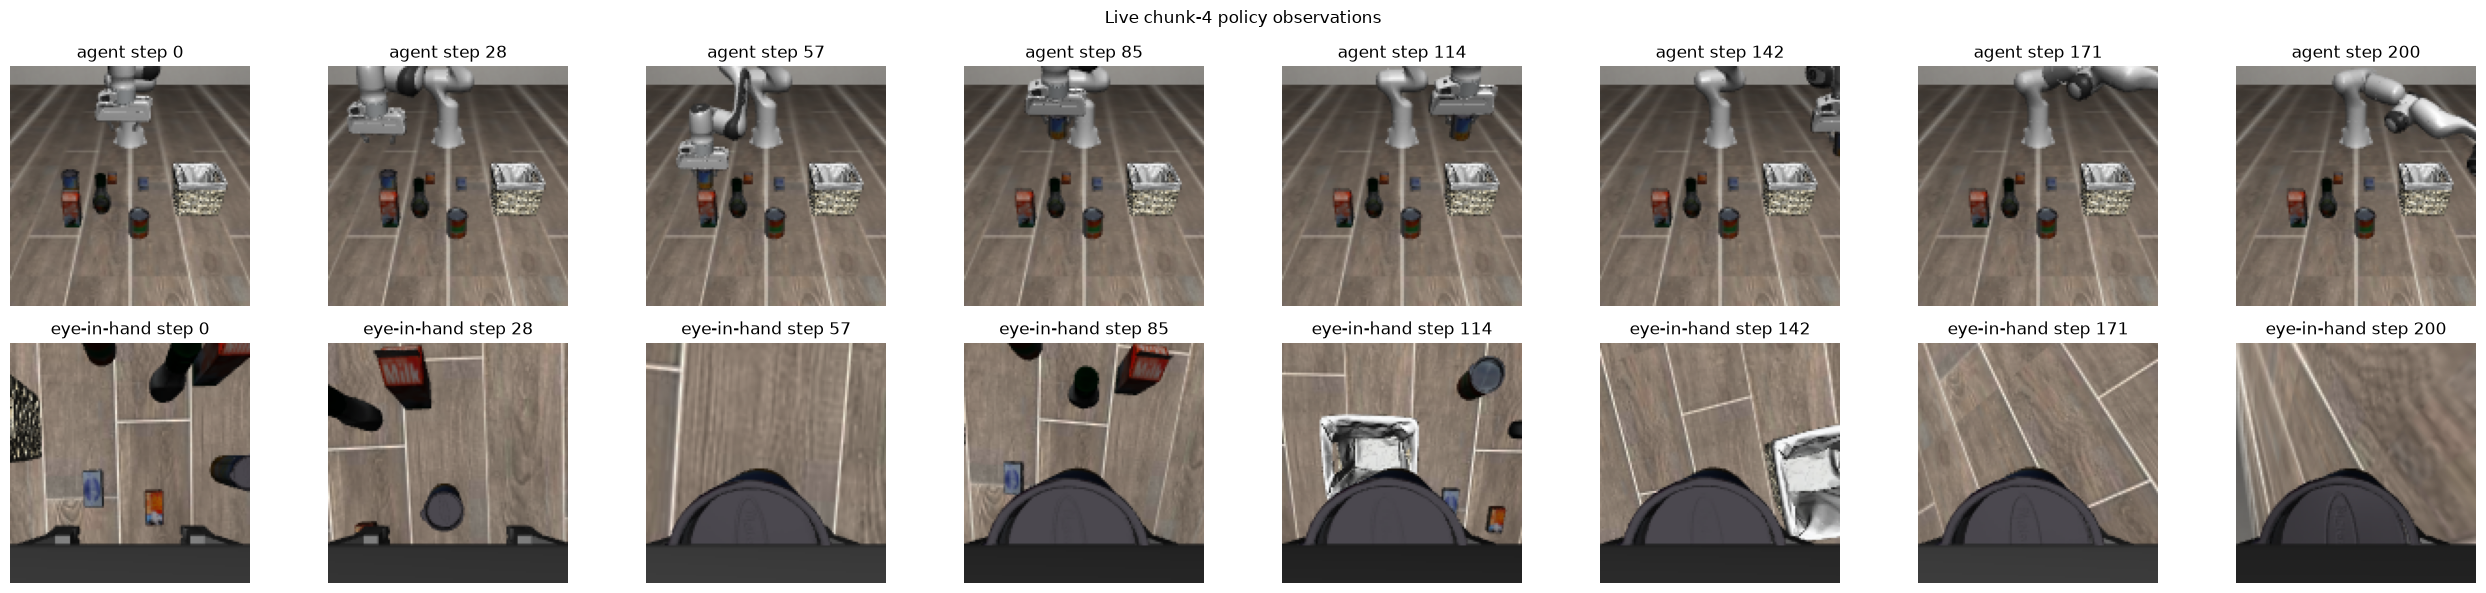

In [48]:
with np.load(LIVE_OBSERVATIONS) as observation_trace:
    live_agent_frames = observation_trace['agent_frames']
    live_wrist_frames = observation_trace['wrist_frames']

camera_indices = np.linspace(0, len(live_agent_frames) - 1, min(8, len(live_agent_frames)), dtype=int)
fig, axes = plt.subplots(2, len(camera_indices), figsize=(3.2 * len(camera_indices), 6), squeeze=False)
for column, frame_index in enumerate(camera_indices):
    axes[0, column].imshow(live_agent_frames[frame_index])
    axes[0, column].set_title(f'agent step {frame_index}')
    axes[0, column].axis('off')
    if len(live_wrist_frames) > frame_index:
        axes[1, column].imshow(live_wrist_frames[frame_index])
        axes[1, column].set_title(f'eye-in-hand step {frame_index}')
    else:
        axes[1, column].text(.5, .5, 'wrist unavailable', ha='center', va='center')
    axes[1, column].axis('off')
fig.suptitle('Live chunk-4 policy observations')
plt.tight_layout()

In [ ]:
# Run after inspecting all plots. Keep cleanup last because some LIBERO builds
# tear down renderer output streams when the environment closes.
if 'controller_env' in globals():
    print('Closing controller replay environment')
    controller_env.close()
    del controller_env
if 'x0_model' in globals():
    print('Releasing traced RDT model and fixed features')
    del x0_model, x0_policy_batch, x0_fixed_batches
    gc.collect()
    torch.cuda.empty_cache()